## Trend Misspecification in Arctic Sea Ice Prediction: A Structural Break in 2007 and the Limited Predictive Value of Winter Climate Indices

**Overview**

Arctic sea ice has declined substantially over the satellite era, with consequences for global climate, ocean circulation, ecosystems and human activity in the region. Seasonal prediction of the September minimum remains an open problem, and simple trend and persistence baselines are difficult to outperform.

This project tests whether winter climate conditions over the Arctic carry predictive information about the following September's sea ice extent, using ERA5 reanalysis variables and NSIDC Sea Ice Index observations for 46 winters spanning 1980 to 2025. Predictors are winter means of 2 m temperature, mean sea level pressure, wind and surface net solar radiation, aggregated over 60°N to 90°N.

Two findings emerge. First, the climate variables provide no predictive information beyond the sea ice record itself. Their apparent correlations with September extent are substantially artefacts of shared trends and do not survive detrending or correction for multiple comparisons. Second, and unexpectedly, the linear trend baseline against which such models are conventionally judged is itself misspecified. A structural break in 2007 separates a period of significant decline from one showing no detectable trend, and correcting for this reduces hold out forecast error by 37%.

The emphasis throughout is on establishing results that hold up rather than on maximising apparent accuracy. Area weighted spatial averaging, detrended correlation analysis, chronological cross validation and explicit baseline comparison were each necessary to reach the conclusions reported here.

# Research Questions

This project aims to answer the following research questions:

1. How has Arctic sea ice extent changed over the satellite observation period?

2. Which climate variables show the strongest relationship with Arctic sea ice extent?

3. Can climate variables improve the prediction of Arctic sea ice compared with using historical sea ice observations alone?

4. Which variables contribute most to model predictions, and are these contributions scientifically interpretable?

# Project Workflow

The project is organised into the following stages:

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Climate Variable Integration
6. Winter Climate Feature Construction
7. Correlation and Detrended Correlation Analysis
8. Predictive Modelling and Baseline Comparison
9. Model Explainability
    - Change Point Analysis
11. Discussion and Conclusions

Each stage builds on the previous one, following a scientific workflow commonly used in climate data analysis.

In [1069]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Date and time handling
from datetime import datetime

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

# Set plotting style
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Data Loading

## Why is this step important?

Before analysing any dataset, it is important to understand where the data come from. Climate datasets are collected using different satellites, sensors, and processing methods. Knowing the source of the data helps us understand what the measurements represent and what limitations they may have.

In this project, we use the **Sea Ice Index Version 4**, published by the **National Snow and Ice Data Center (NSIDC)**.

### Dataset Information

- **Dataset:** Sea Ice Index, Version 4
- **Provider:** National Snow and Ice Data Center (NSIDC)
- **DOI:** 10.7265/a98x-0f50
- **Time Period:** November 1978 – Present
- **Spatial Resolution:** 25 km
- **Temporal Resolution:** Monthly
- **Variable Used:** Northern Hemisphere Sea Ice Extent

The dataset is considered one of the standard references for Arctic sea ice research and is widely used in climate science.

In [1070]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/shwetadsarkar/monthly-data-by-year/Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0 (1).xlsx
/kaggle/input/datasets/shwetadsarkar/era5-dataset-2/data_stream-moda_stepType-avgad.nc
/kaggle/input/datasets/shwetadsarkar/era5-dataset-2/data_stream-moda_stepType-avgua.nc


In [1071]:
# ==========================================================
# Load the NSIDC Sea Ice Dataset
# ==========================================================

# Replace this path with your own location
file_path = "/kaggle/input/datasets/shwetadsarkar/monthly-data-by-year/Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0 (1).xlsx"

# Read the Northern Hemisphere extent sheet
sea_ice_raw = pd.read_excel(
    file_path,
    sheet_name="NH-Extent"
)

print("Dataset loaded successfully.\n")

# Display the first five rows
sea_ice_raw.head()

Dataset loaded successfully.



,Unnamed: 0,January,February,March,April,May,June,July,August,September,October,November,December,Unnamed: 13,Annual
0,1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.645,13.667,NaN,12.673
1,1979,15.414,16.175,16.342,15.447,13.857,12.530,10.311,8.041,7.051,8.748,10.943,13.336,NaN,12.328
2,1980,14.862,15.955,16.041,15.429,13.793,12.205,10.100,7.984,7.667,9.183,11.383,13.593,NaN,12.337
3,1981,14.910,15.604,15.632,15.010,13.802,12.430,10.271,7.844,7.138,8.856,10.929,13.341,NaN,12.127
4,1982,15.177,15.974,16.044,15.466,13.973,12.476,10.367,8.139,7.302,9.421,11.627,13.642,NaN,12.447


# 2. Data Understanding

Before cleaning or transforming the dataset, it is important to understand its structure and contents.

In this section, we examine:

- the number of rows and columns,
- the column names,
- the data types,
- missing values,
- and the overall organisation of the dataset.

Understanding the raw data helps identify potential quality issues before any preprocessing is performed.

In [1072]:
# ==========================================================
# Basic Information About the Dataset
# ==========================================================

print("Dataset Shape:")
print(sea_ice_raw.shape)

print("\nColumn Names:")
print(sea_ice_raw.columns.tolist())

print("\nData Types:")
print(sea_ice_raw.dtypes)

print("\nMissing Values:")
print(sea_ice_raw.isnull().sum())

Dataset Shape:
(49, 15)

Column Names:
['Unnamed: 0', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Unnamed: 13', 'Annual']

Data Types:
Unnamed: 0       int64
January        float64
February       float64
March          float64
April          float64
                ...   
October        float64
November       float64
December       float64
Unnamed: 13    float64
Annual         float64
Length: 15, dtype: object

Missing Values:
Unnamed: 0      0
January         2
February        1
March           1
April           1
               ..
October         2
November        1
December        2
Unnamed: 13    49
Annual          0
Length: 15, dtype: int64


# 3. Data Cleaning

The raw dataset is organised for human readability rather than data analysis. Before performing statistical analysis or building prediction models, the dataset must be cleaned and transformed into a suitable format.

The cleaning process in this project includes:

- Removing unnecessary columns.
- Renaming columns.
- Removing incomplete records.
- Converting the dataset from wide format to long format.
- Creating a proper datetime variable.

These steps improve data quality while preserving the original measurements.

In [1073]:
# ==========================================================
# Create a Working Copy
# ==========================================================

# Keep the original dataset unchanged
sea_ice = sea_ice_raw.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [1074]:
# ==========================================================
# Remove Unnecessary Columns
# ==========================================================

# Drop empty and unused columns
sea_ice = sea_ice.drop(columns=["Unnamed: 13"])

# Rename the first column
sea_ice = sea_ice.rename(columns={"Unnamed: 0": "Year"})

sea_ice.head()

,Year,January,February,March,April,May,June,July,August,September,October,November,December,Annual
0,1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.645,13.667,12.673
1,1979,15.414,16.175,16.342,15.447,13.857,12.530,10.311,8.041,7.051,8.748,10.943,13.336,12.328
2,1980,14.862,15.955,16.041,15.429,13.793,12.205,10.100,7.984,7.667,9.183,11.383,13.593,12.337
3,1981,14.910,15.604,15.632,15.010,13.802,12.430,10.271,7.844,7.138,8.856,10.929,13.341,12.127
4,1982,15.177,15.974,16.044,15.466,13.973,12.476,10.367,8.139,7.302,9.421,11.627,13.642,12.447


In [1075]:
# ==========================================================
# Verify the Cleaning
# ==========================================================

print("Shape of cleaned dataset:")
print(sea_ice.shape)

print("\nColumn names:")
print(sea_ice.columns.tolist())

display(sea_ice.head())

Shape of cleaned dataset:
(49, 14)

Column names:
['Year', 'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December', 'Annual']


,Year,January,February,March,April,May,June,July,August,September,October,November,December,Annual
0,1978,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.645,13.667,12.673
1,1979,15.414,16.175,16.342,15.447,13.857,12.530,10.311,8.041,7.051,8.748,10.943,13.336,12.328
2,1980,14.862,15.955,16.041,15.429,13.793,12.205,10.100,7.984,7.667,9.183,11.383,13.593,12.337
3,1981,14.910,15.604,15.632,15.010,13.802,12.430,10.271,7.844,7.138,8.856,10.929,13.341,12.127
4,1982,15.177,15.974,16.044,15.466,13.973,12.476,10.367,8.139,7.302,9.421,11.627,13.642,12.447


## Removing Incomplete Years
The first and last years of the record are incomplete: satellite observations begin in late 1978, and the most recent year may not yet contain all twelve months. Since September sea ice extent is the target variable, only years with a valid September observation are retained.

Two years within the retained period contain a single missing month. December 1987 and January 1988 are absent from the Sea Ice Index because of a failure of the SSMI instrument aboard the DMSP F8 satellite. September values for both years are unaffected, so these years are retained. This gap is noted because it slightly reduces the sample size for those two months in the monthly summaries that follow.

In [1076]:
# ==========================================================
# Identify Years with Missing Monthly Values
# ==========================================================

# Count missing values in each row
missing_per_year = sea_ice.isnull().sum(axis=1)

# Display years with missing data
incomplete_years = sea_ice.loc[missing_per_year > 0, "Year"]

print("Incomplete years:")
print(incomplete_years.tolist())

Incomplete years:
[1978, 1987, 1988, 2026]


In [1077]:
# Keep only years where September sea ice is available
sea_ice = sea_ice.dropna(subset=["September"]).reset_index(drop=True)

print("New dataset shape:")
print(sea_ice.shape)

display(sea_ice.head())
display(sea_ice.tail())

New dataset shape:
(47, 14)


,Year,January,February,March,April,May,June,July,August,September,October,November,December,Annual
0,1979,15.414,16.175,16.342,15.447,13.857,12.530,10.311,8.041,7.051,8.748,10.943,13.336,12.328
1,1980,14.862,15.955,16.041,15.429,13.793,12.205,10.100,7.984,7.667,9.183,11.383,13.593,12.337
2,1981,14.910,15.604,15.632,15.010,13.802,12.430,10.271,7.844,7.138,8.856,10.929,13.341,12.127
3,1982,15.177,15.974,16.044,15.466,13.973,12.476,10.367,8.139,7.302,9.421,11.627,13.642,12.447
4,1983,14.942,16.006,16.085,15.172,13.491,12.296,10.570,8.186,7.395,9.334,11.461,13.299,12.332


,Year,January,February,March,April,May,June,July,August,September,October,November,December,Annual
42,2021,13.501,14.390,14.658,13.792,12.682,10.765,7.647,5.715,4.952,6.816,9.830,12.152,10.552
43,2022,13.872,14.612,14.586,13.986,12.879,10.875,8.287,5.950,4.897,6.657,9.725,11.892,10.661
44,2023,13.364,14.189,14.430,13.924,12.822,10.987,8.207,5.514,4.381,6.412,9.682,11.978,10.469
45,2024,13.917,14.607,14.868,14.041,12.735,10.854,7.870,5.130,4.351,5.934,9.146,11.408,10.391
46,2025,13.110,13.745,14.119,13.829,12.494,10.405,7.660,5.395,4.747,6.317,8.775,11.222,10.130


## Converting the Dataset from Wide Format to Long Format

The current dataset stores each month as a separate column. While this format is convenient for viewing in a spreadsheet, it is not ideal for time-series analysis.

To analyse monthly changes over time, the dataset is transformed into a **long format**, where each row represents a single monthly observation.

After transformation, each observation contains:

- Year
- Month
- Sea Ice Extent

This structure is the standard format used for time-series analysis and data visualisation.

In [1078]:
# ==========================================================
# Convert the Dataset to Long Format
# ==========================================================

sea_ice_long = sea_ice.melt(
    id_vars="Year",
    value_vars=[
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ],
    var_name="Month",
    value_name="Sea_Ice_Extent"
)

print("Shape of the long-format dataset:")
print(sea_ice_long.shape)

display(sea_ice_long.head(15))

Shape of the long-format dataset:
(564, 3)


,Year,Month,Sea_Ice_Extent
0,1979,January,15.414
1,1980,January,14.862
2,1981,January,14.910
3,1982,January,15.177
4,1983,January,14.942
...,...,...,...
10,1989,January,14.955
11,1990,January,14.783
12,1991,January,14.364
13,1992,January,14.643


### Organising the Dataset Chronologically

After converting the dataset into long format, the monthly observations are grouped by month rather than by time.

To prepare the data for time-series analysis, we create a proper date column and sort the observations into chronological order.

In [1079]:
# ==========================================================
# Create a Date Column
# ==========================================================

# Combine the Year and Month columns into a single datetime column
sea_ice_long["Date"] = pd.to_datetime(
    sea_ice_long["Year"].astype(str) + "-" + sea_ice_long["Month"],
    format="%Y-%B"
)

# Sort the dataset chronologically
sea_ice_long = sea_ice_long.sort_values("Date").reset_index(drop=True)

print("Dataset sorted chronologically.")

display(sea_ice_long.head(15))

Dataset sorted chronologically.


,Year,Month,Sea_Ice_Extent,Date
0,1979,January,15.414,1979-01-01
1,1979,February,16.175,1979-02-01
2,1979,March,16.342,1979-03-01
3,1979,April,15.447,1979-04-01
4,1979,May,13.857,1979-05-01
...,...,...,...,...
10,1979,November,10.943,1979-11-01
11,1979,December,13.336,1979-12-01
12,1980,January,14.862,1980-01-01
13,1980,February,15.955,1980-02-01


## Saving the Cleaned Dataset

The dataset has now been cleaned and transformed into a format suitable for analysis.

Saving the cleaned dataset improves reproducibility and allows later stages of the project to use the processed data directly without repeating the cleaning steps.

In [1080]:
# ==========================================================
# Save the Cleaned Dataset
# ==========================================================

sea_ice_long.to_csv("cleaned_sea_ice_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of understanding a dataset before building prediction models.

The purpose of EDA is to identify important patterns, trends, seasonal behaviour, and potential anomalies within the data.

Rather than immediately applying machine learning algorithms, we first investigate the characteristics of Arctic sea ice over time. This helps ensure that later modelling decisions are based on evidence from the data rather than assumptions.

The following questions guide this analysis:

- How has Arctic sea ice changed over time?
- Does sea ice follow a seasonal cycle?
- Which months have the highest and lowest sea ice extent?
- Are there unusual years or observations?
- What patterns might help predict future sea ice conditions?

## 4.1 Dataset Summary

Before exploring trends and seasonal patterns, it is useful to summarise the main characteristics of the cleaned dataset.

This includes:

- Number of observations
- Time period covered
- Number of years
- Mean sea ice extent
- Minimum and maximum values
- Standard deviation

These statistics provide an overview of the data before more detailed analyses are performed.

In [1081]:
# ==========================================================
# Dataset Summary
# ==========================================================

print("Number of observations :", len(sea_ice_long))
print("Number of years        :", sea_ice_long["Year"].nunique())
print("Start year             :", sea_ice_long["Year"].min())
print("End year               :", sea_ice_long["Year"].max())

print("\nSea Ice Extent Statistics")

print(sea_ice_long["Sea_Ice_Extent"].describe())

Number of observations : 564
Number of years        : 47
Start year             : 1979
End year               : 2025

Sea Ice Extent Statistics
count    562.000000
mean      11.294918
std        3.290082
min        3.566000
25%        8.461250
50%       11.992000
75%       14.203000
max       16.342000
Name: Sea_Ice_Extent, dtype: float64


## 4.2 Seasonal Cycle of Arctic Sea Ice

### Scientific Question

How does Arctic sea ice extent change throughout the year?

### Why is this important?

Arctic sea ice naturally grows during autumn and winter and melts during spring and summer.

Understanding this seasonal cycle is important because it provides the physical context for later prediction models. It also helps identify the months with the greatest and least sea ice coverage.

### Hypothesis

Based on previous climate studies, we expect:

- Sea ice extent to increase during autumn and winter.
- Maximum sea ice extent to occur around March.
- Minimum sea ice extent to occur around September.
- 

In [1082]:
# ==========================================================
# Mean Sea Ice Extent for Each Month
# ==========================================================

monthly_average = (
    sea_ice_long
    .groupby("Month")["Sea_Ice_Extent"]
    .mean()
)

# Arrange the months in calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_average = monthly_average.reindex(month_order)

display(monthly_average)

Month
January      14.159087
February     15.031638
March        15.192979
April        14.474574
May          13.085404
               ...    
August        6.682319
September     5.874489
October       7.756702
November     10.337894
December     12.551457
Name: Sea_Ice_Extent, Length: 12, dtype: float64

### Visualising the Seasonal Cycle

The table above provides the average sea ice extent for each month across the entire study period.

To better understand the seasonal behaviour, these monthly averages are visualised using a line chart.

The figure highlights the annual growth and melt cycle of Arctic sea ice.


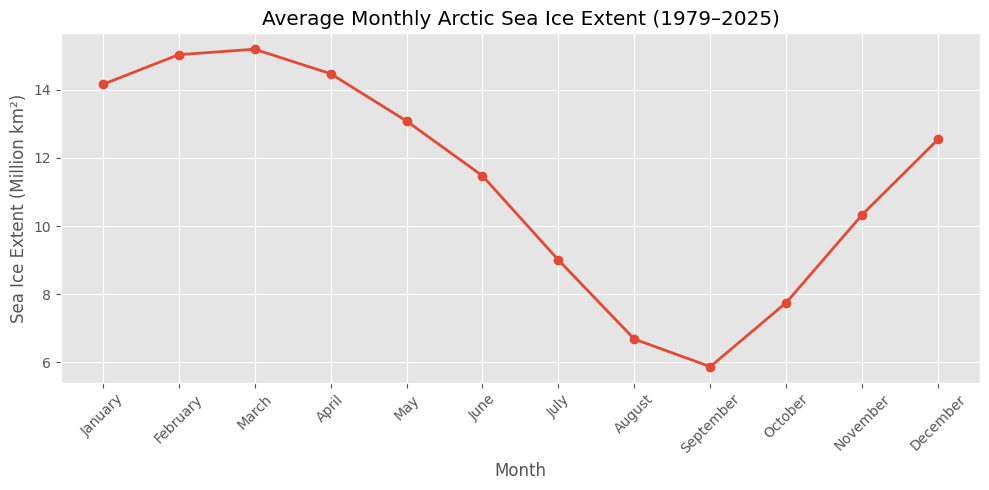

In [1083]:
# ==========================================================
# Seasonal Cycle of Arctic Sea Ice
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Arctic Sea Ice Extent (1979–2025)")
plt.xlabel("Month")
plt.ylabel("Sea Ice Extent (Million km²)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Improving the Visualization

The previous figure clearly illustrated the seasonal cycle of Arctic sea ice. However, the months with the highest and lowest average sea ice extent were not immediately obvious.

To improve the readability of the figure, the maximum and minimum average sea ice extent are highlighted. This makes it easier to identify the peak winter extent and the minimum summer extent.

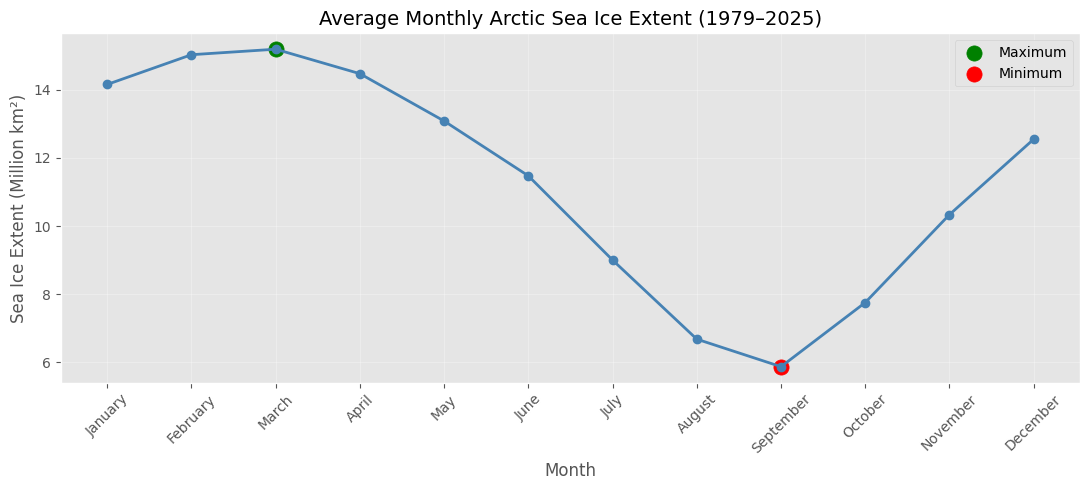

In [1084]:
# ==========================================================
# Seasonal Cycle with Maximum and Minimum Highlighted
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o",
    linewidth=2,
    color="steelblue"
)

# Highlight maximum
max_month = monthly_average.idxmax()
max_value = monthly_average.max()

plt.scatter(max_month, max_value,
            color="green",
            s=120,
            label="Maximum")

# Highlight minimum
min_month = monthly_average.idxmin()
min_value = monthly_average.min()

plt.scatter(min_month, min_value,
            color="red",
            s=120,
            label="Minimum")

plt.title("Average Monthly Arctic Sea Ice Extent (1979–2025)", fontsize=14)

plt.xlabel("Month")
plt.ylabel("Sea Ice Extent (Million km²)")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## 4.3 Long-Term Trend Analysis

### Scientific Question

Has Arctic sea ice extent changed over the last 47 years?

### Why is this important?

While the previous section showed the seasonal cycle within a single year, this analysis investigates whether Arctic sea ice has changed over multiple decades.

A long-term decline would indicate that the Arctic climate is changing over time. Understanding this trend provides the motivation for developing predictive models later in the project.

### Hypothesis

Based on previous climate studies, we expect Arctic sea ice extent to show a decreasing trend from 1979 to 2025.

In [1085]:
# ==========================================================
# Create Annual Sea Ice Dataset
# ==========================================================

# Select only the Year and Annual columns
annual_sea_ice = sea_ice[["Year", "Annual"]].copy()

# Display the first few rows
display(annual_sea_ice.head())

,Year,Annual
0,1979,12.328
1,1980,12.337
2,1981,12.127
3,1982,12.447
4,1983,12.332


### Visualising the Long-Term Trend

The annual average sea ice extent is plotted against time to investigate whether Arctic sea ice has changed over the satellite observation period.

Unlike the seasonal analysis, which focused on changes within a year, this figure highlights changes across multiple decades.

If a downward trend is observed, it provides evidence that Arctic sea ice has declined over time.

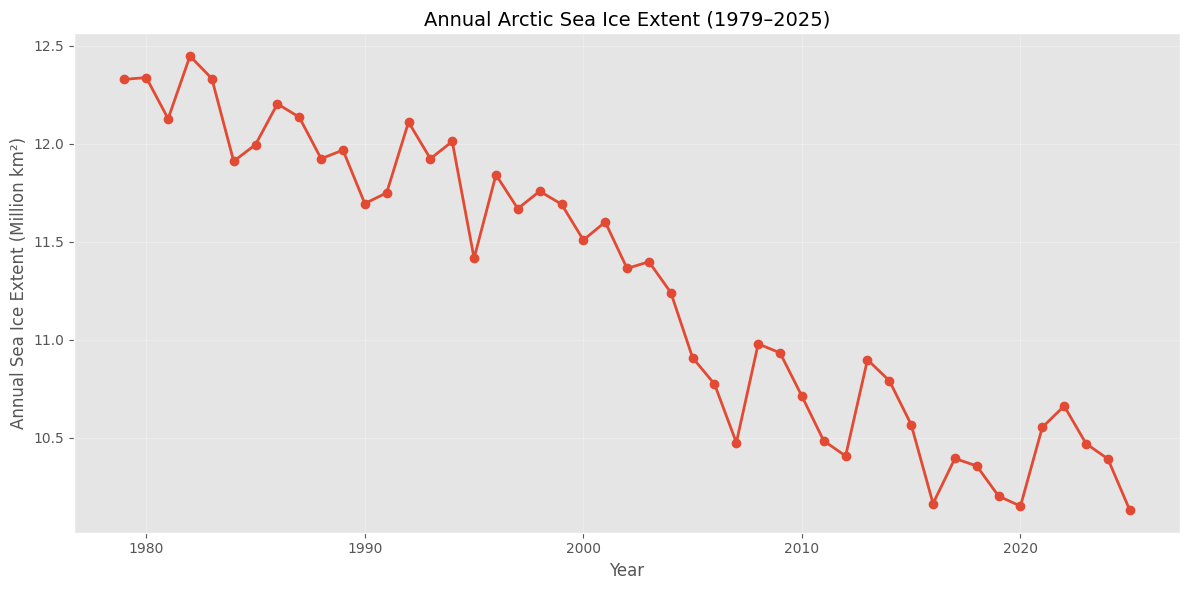

In [1086]:
# ==========================================================
# Long-Term Trend of Arctic Sea Ice
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    annual_sea_ice["Year"],
    annual_sea_ice["Annual"],
    marker="o",
    linewidth=2
)

plt.title("Annual Arctic Sea Ice Extent (1979–2025)", fontsize=14)

plt.xlabel("Year")

plt.ylabel("Annual Sea Ice Extent (Million km²)")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### Adding a Trend Line

The annual values fluctuate naturally from year to year because of climate variability.

To better understand the long-term behaviour, a linear trend line is added.

The trend line does not describe every individual year. Instead, it summarises the overall direction of change across the entire observation period.

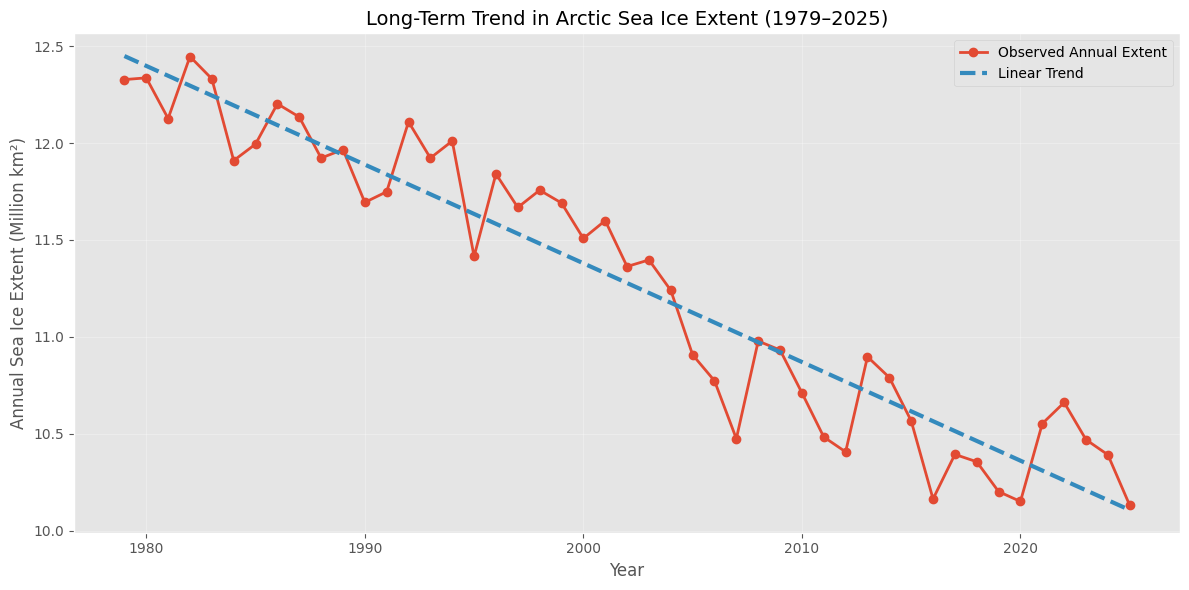

In [1087]:
# ==========================================================
# Annual Sea Ice Extent with Linear Trend
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# Fit a straight line to the data
coefficients = np.polyfit(
    annual_sea_ice["Year"],
    annual_sea_ice["Annual"],
    1
)

trend = np.poly1d(coefficients)

plt.figure(figsize=(12,6))

# Original observations
plt.plot(
    annual_sea_ice["Year"],
    annual_sea_ice["Annual"],
    marker="o",
    linewidth=2,
    label="Observed Annual Extent"
)

# Trend line
plt.plot(
    annual_sea_ice["Year"],
    trend(annual_sea_ice["Year"]),
    linestyle="--",
    linewidth=3,
    label="Linear Trend"
)

plt.title("Long-Term Trend in Arctic Sea Ice Extent (1979–2025)", fontsize=14)

plt.xlabel("Year")

plt.ylabel("Annual Sea Ice Extent (Million km²)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## 4.4 Monthly Trends

### Scientific Question

Do all months show the same long-term decline in Arctic sea ice?

### Why is this important?

The previous analysis considered only the annual average sea ice extent. However, Arctic sea ice changes throughout the year.

By studying each month separately, we can determine whether some seasons are experiencing a faster decline than others.

This provides a more detailed understanding of Arctic climate change.

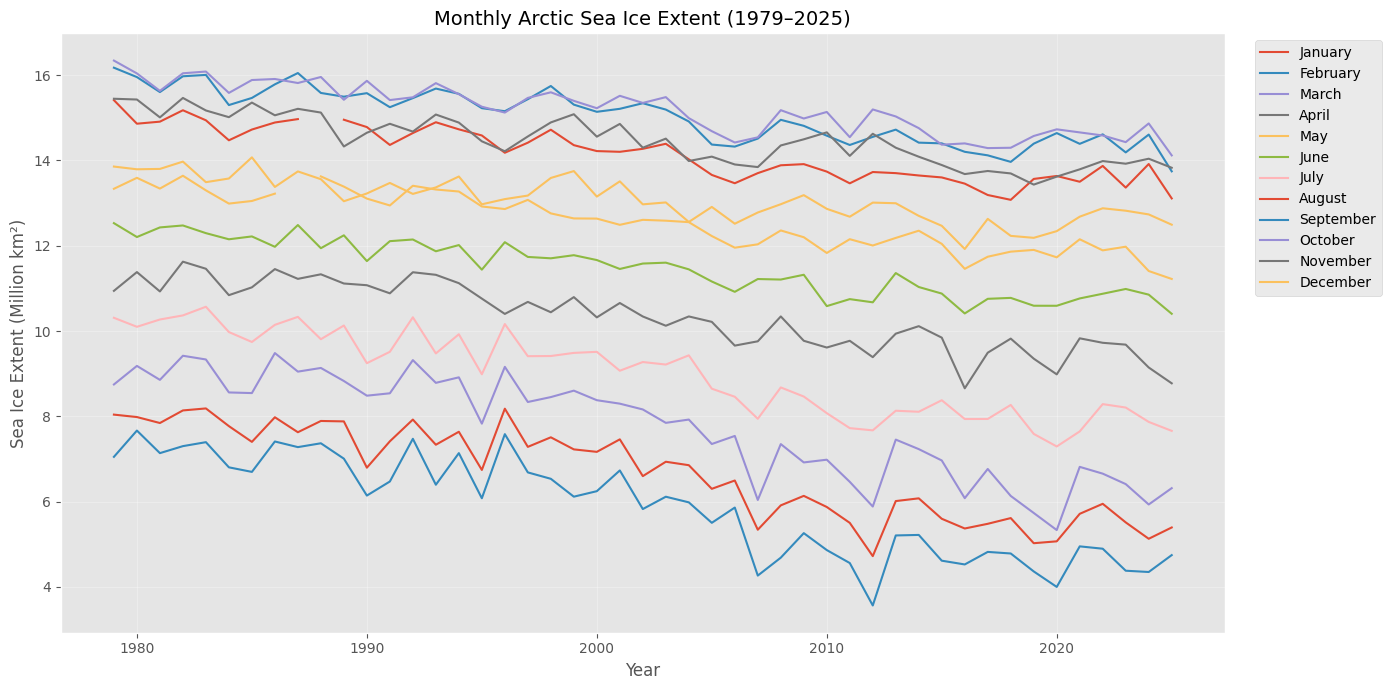

In [1088]:
# ==========================================================
# Sea Ice Trends for Each Month
# ==========================================================

import matplotlib.pyplot as plt

# Create a larger figure
plt.figure(figsize=(14, 7))

# Loop through each month
for month in sea_ice_long["Month"].unique():

    # Select data for one month
    month_data = sea_ice_long[sea_ice_long["Month"] == month]

    # Plot the monthly trend
    plt.plot(
        month_data["Year"],
        month_data["Sea_Ice_Extent"],
        label=month
    )

plt.title("Monthly Arctic Sea Ice Extent (1979–2025)", fontsize=14)

plt.xlabel("Year")

plt.ylabel("Sea Ice Extent (Million km²)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 4.5 Monthly Decline Analysis

### Scientific Question

Which months have experienced the greatest decline in Arctic sea ice between 1979 and 2025?

### Why is this important?

The previous figure showed how sea ice changes over time for each month. However, comparing twelve different time series is difficult.

Instead, we calculate the total change in sea ice extent between the first and last year of the dataset for each month. This provides a simple summary of which seasons have experienced the largest long-term decline.

In [1089]:
# ==========================================================
# Calculate the change in sea ice extent for each month
# ==========================================================

monthly_change = []

for month in sea_ice_long["Month"].unique():

    month_data = sea_ice_long[
        sea_ice_long["Month"] == month
    ]

    first_year = month_data.iloc[0]["Sea_Ice_Extent"]
    last_year = month_data.iloc[-1]["Sea_Ice_Extent"]

    decline = last_year - first_year

    monthly_change.append([month, decline])

monthly_change = pd.DataFrame(
    monthly_change,
    columns=["Month", "Change"]
)

monthly_change

,Month,Change
0,January,-2.304
1,February,-2.430
2,March,-2.223
3,April,-1.618
4,May,-1.363
...,...,...
7,August,-2.646
8,September,-2.304
9,October,-2.431
10,November,-2.168


### Visualising Monthly Sea Ice Loss

The calculated changes are displayed as a bar chart to compare how much sea ice has changed in each month between 1979 and 2025.

Months with larger negative values have experienced a greater reduction in sea ice extent over the study period.

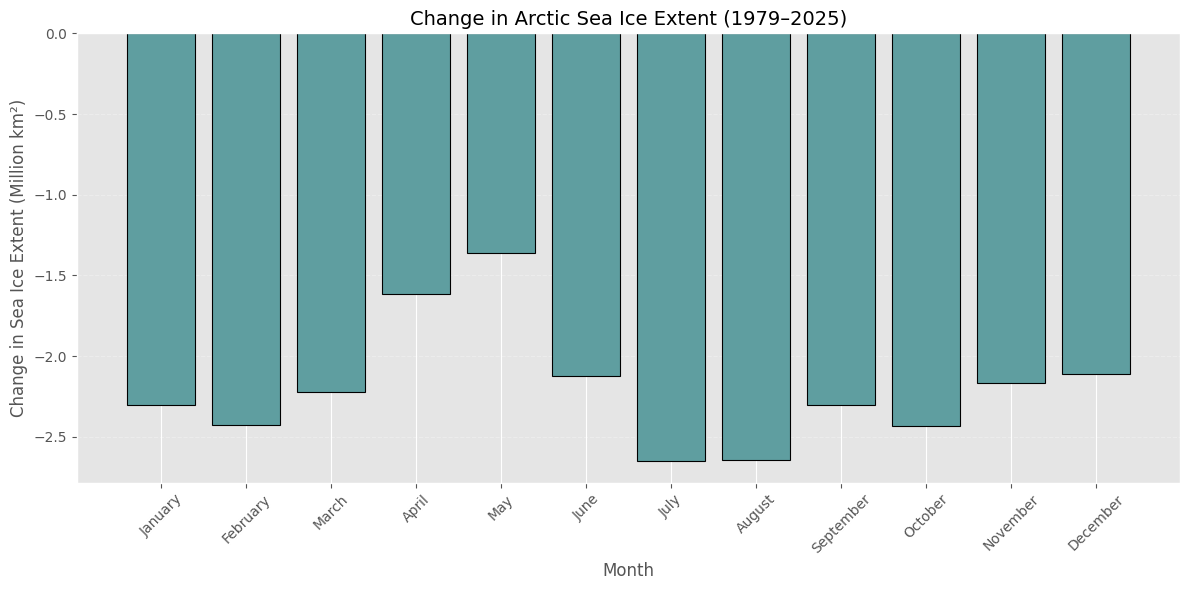

In [1090]:
# ==========================================================
# Monthly Change in Arctic Sea Ice Extent
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_change["Month"],
    monthly_change["Change"],
    color="cadetblue",
    edgecolor="black",
    linewidth=0.8
)

plt.title(
    "Change in Arctic Sea Ice Extent (1979–2025)",
    fontsize=14
)

plt.xlabel("Month", fontsize=12)

plt.ylabel("Change in Sea Ice Extent (Million km²)", fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 4.6 Extreme Years

### Scientific Question

Which years recorded the highest and lowest annual Arctic sea ice extent?

### Why is this important?

Identifying years with exceptionally high or low sea ice extent helps us understand the range of variability in the Arctic climate.

These extreme years may be associated with unusual atmospheric or oceanic conditions and provide useful case studies for later analyses involving climate variables.

In [1091]:
# ==========================================================
# Identify the Highest and Lowest Annual Sea Ice Extent
# ==========================================================

# Year with the highest annual sea ice extent
highest_year = annual_sea_ice.loc[
    annual_sea_ice["Annual"].idxmax()
]

# Year with the lowest annual sea ice extent
lowest_year = annual_sea_ice.loc[
    annual_sea_ice["Annual"].idxmin()
]

print("Highest Annual Sea Ice Extent")
display(highest_year)

print()

print("Lowest Annual Sea Ice Extent")
display(lowest_year)

Highest Annual Sea Ice Extent


Year      1982.000
Annual      12.447
Name: 3, dtype: float64


Lowest Annual Sea Ice Extent


Year      2025.00
Annual      10.13
Name: 46, dtype: float64

### Highlighting the Extreme Years

The years with the highest and lowest annual sea ice extent are highlighted on the long-term trend.

This helps place the extreme observations within the overall decline in Arctic sea ice and provides additional context for interpreting long-term changes.

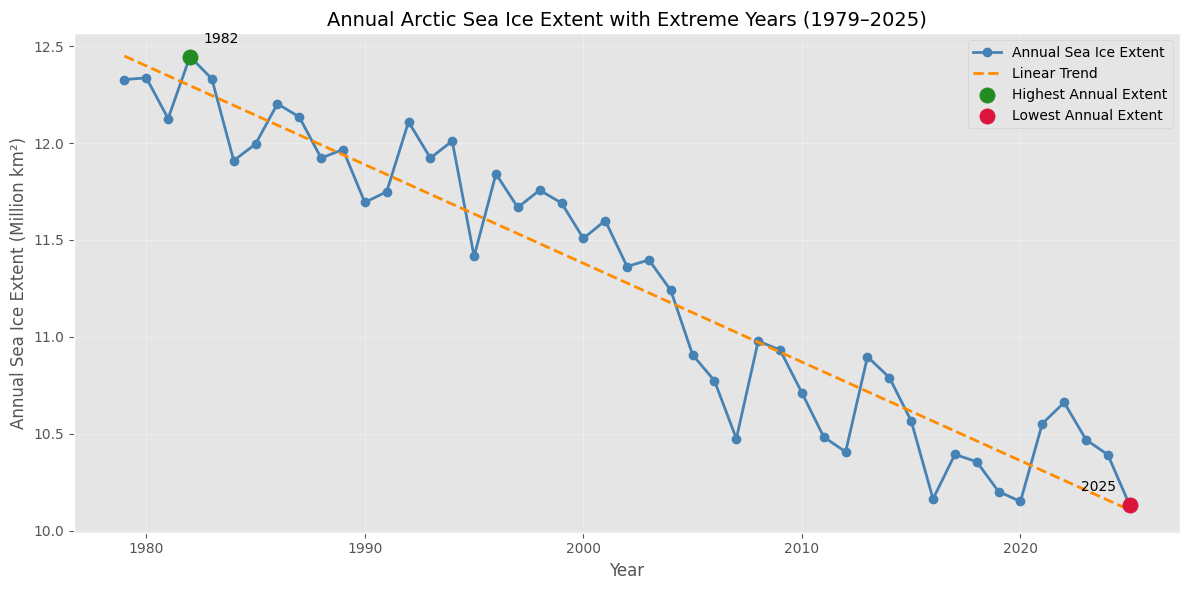

In [1092]:
# ==========================================================
# Annual Sea Ice Trend with Highest and Lowest Years Highlighted
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# Calculate the linear trend
coefficients = np.polyfit(
    annual_sea_ice["Year"],
    annual_sea_ice["Annual"],
    1
)

trend = np.poly1d(coefficients)

plt.figure(figsize=(12, 6))

# Plot annual observations
plt.plot(
    annual_sea_ice["Year"],
    annual_sea_ice["Annual"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Annual Sea Ice Extent"
)

# Plot trend line
plt.plot(
    annual_sea_ice["Year"],
    trend(annual_sea_ice["Year"]),
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="Linear Trend"
)

# Highlight highest year
plt.scatter(
    highest_year["Year"],
    highest_year["Annual"],
    color="forestgreen",
    s=120,
    zorder=5,
    label="Highest Annual Extent"
)

# Highlight lowest year
plt.scatter(
    lowest_year["Year"],
    lowest_year["Annual"],
    color="crimson",
    s=120,
    zorder=5,
    label="Lowest Annual Extent"
)

# Annotate highest year
plt.annotate(
    f'{int(highest_year["Year"])}',
    (highest_year["Year"], highest_year["Annual"]),
    xytext=(10, 10),
    textcoords="offset points"
)

plt.annotate(
    f'{int(lowest_year["Year"])}',
    (lowest_year["Year"], lowest_year["Annual"]),
    xytext=(-35, 10),
    textcoords="offset points",
    fontsize=10
)

plt.title("Annual Arctic Sea Ice Extent with Extreme Years (1979–2025)", fontsize=14)

plt.xlabel("Year")

plt.ylabel("Annual Sea Ice Extent (Million km²)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# 5. Climate Variable Integration

## Why do we need climate variables?

So far, we have analysed only the observed Arctic sea ice extent.

Although these analyses describe how sea ice has changed over time, they do not explain why these changes occurred.

To investigate the physical processes behind sea ice variability, additional climate variables are required.

These variables represent atmospheric and oceanic conditions that influence the growth and melting of Arctic sea ice.

In the following sections, we will identify suitable climate variables and combine them with the sea ice observations to create a single modelling dataset.

## Candidate Climate Variables

Based on climate science literature, several environmental variables are known to influence Arctic sea ice.

| Variable | Why it matters |
|-----------|----------------|
| Air Temperature | Warmer air increases melting. |
| Sea Surface Temperature (SST) | Warmer oceans melt sea ice from below. |
| Sea Level Pressure (SLP) | Influences atmospheric circulation and winds. |
| Wind Components (U and V) | Move and redistribute sea ice. |
| Ocean Heat Content | Supplies heat to the Arctic Ocean. |
| Downward Solar Radiation | Provides energy for surface melting. |
| Snowfall / Precipitation | Changes insulation and surface reflectivity. |

## Climate Variable 1: 2 m Air Temperature

### What is 2 m Air Temperature?

Air temperature measures how hot or cold the air is.

In climate datasets such as ERA5, temperature is measured at a standard height of **2 metres above the Earth's surface**. This height is used internationally because it represents near-surface atmospheric conditions while avoiding direct influence from the ground.

### Why is it important?

Air temperature controls the exchange of heat between the atmosphere and the sea ice.

Higher air temperatures increase surface melting and reduce the formation of new ice during winter. As a result, warmer conditions generally lead to a reduction in Arctic sea ice extent.

### Why will we use it?

Because air temperature is one of the primary physical drivers of sea ice growth and melting, it is expected to be an important predictor in our machine learning models.

## Climate Variable 2: Sea Surface Temperature (SST)

### What is Sea Surface Temperature?

Sea Surface Temperature (SST) is the temperature of the upper layer of the ocean.

Since Arctic sea ice floats on the ocean, the temperature of the surrounding seawater strongly influences the rate at which sea ice grows or melts.

### Why is it important?

Warm ocean water transfers heat to the underside of sea ice, increasing bottom melting.

Unlike air temperature, which mainly affects the surface of the ice, sea surface temperature influences the ice from below.

### Why will we use it?

Sea Surface Temperature represents the ocean's contribution to sea ice change and complements the effect of air temperature.

Including both variables allows the model to capture both atmospheric and oceanic influences on Arctic sea ice.


## Climate Variable 3: Mean Sea Level Pressure (MSLP)

### What is Mean Sea Level Pressure?

Mean Sea Level Pressure (MSLP) is the atmospheric pressure adjusted to sea level.

It describes the weight of the atmosphere above the Earth's surface and is commonly used to identify weather systems and atmospheric circulation patterns.

### Why is it important?

Sea level pressure does not melt sea ice directly.

Instead, it influences atmospheric circulation and wind patterns, which can transport, compress, or disperse sea ice across the Arctic Ocean.

### Why will we use it?

Mean Sea Level Pressure provides information about large-scale weather patterns that influence sea ice movement and distribution.

Including this variable allows the model to account for atmospheric circulation in addition to temperature.

## Climate Variable 4: 10 m Wind Components (U and V)

### What are the U and V wind components?

Wind has both a speed and a direction.

Instead of storing wind as a single speed value, climate datasets represent it using two components:

- **U-component:** East–west wind movement.
- **V-component:** North–south wind movement.

Together, these components fully describe the movement of air.

### Why are they important?

Wind transports, compresses, and redistributes Arctic sea ice.

Strong winds can move sea ice over large distances, create areas of open water, and influence the exchange of heat between the atmosphere and the ocean.

### Why will we use them?

The U and V wind components allow the model to capture both the strength and direction of atmospheric motion, making them more informative than wind speed alone.

## Climate Variable 5: Surface Solar Radiation

### What is Surface Solar Radiation?

Surface solar radiation is the amount of solar energy that reaches the Earth's surface.

It provides energy that can warm the surface and contribute to the melting of Arctic sea ice.

### Why is it important?

During spring and summer, increased solar radiation supplies additional energy for melting sea ice.

As sea ice decreases, more dark ocean water is exposed, allowing the ocean to absorb more solar energy. This process, known as the ice–albedo feedback, can accelerate further melting.

### Why will we use it?

Surface solar radiation represents the amount of incoming energy from the Sun and complements atmospheric and oceanic temperature variables in explaining changes in sea ice.

## Climate Variable 6: Total Precipitation

### What is Total Precipitation?

Total precipitation is the total amount of water falling from the atmosphere, including rain and snow.

In the Arctic, much of the precipitation occurs as snowfall, particularly during winter.

### Why is it important?

Snowfall changes the thickness of the snow layer covering sea ice.

This snow layer acts as an insulator, influencing the transfer of heat between the atmosphere, the ocean, and the sea ice.

Rainfall can also contribute to melting during warmer periods.

### Why will we use it?

Total precipitation provides additional information about surface conditions that influence sea ice growth and melting.

Although its effect is more indirect than temperature, it complements the other climate variables by describing seasonal changes in precipitation.

In [1093]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("\nFolder:", root)
    for file in files:
        print("  ", file)


Folder: /kaggle/input

Folder: /kaggle/input/datasets

Folder: /kaggle/input/datasets/shwetadsarkar

Folder: /kaggle/input/datasets/shwetadsarkar/monthly-data-by-year
   Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0 (1).xlsx

Folder: /kaggle/input/datasets/shwetadsarkar/era5-dataset-2
   data_stream-moda_stepType-avgad.nc
   data_stream-moda_stepType-avgua.nc


# ERA5 Climate Data

The ERA5 reanalysis dataset provides physically consistent estimates of atmospheric conditions over time. In this project, winter climate variables are used as potential predictors of September Arctic sea ice extent.

The selected variables include:

- 2 metre temperature (t2m)
- Mean sea level pressure (msl)
- 10 metre U wind component (u10)
- 10 metre V wind component (v10)
- Surface net solar radiation (ssr)

The dataset covers the period from 1979 to 2025 and includes only the winter months (December, January, February, and March) over the Arctic region.

## Loading the ERA5 Climate Data

The ERA5 climate variables were downloaded from the Copernicus Climate Data Store.

The download contains two NetCDF files:

- One file contains atmospheric variables (temperature, pressure and wind).
- One file contains radiation variables.

These files will be loaded separately and merged after preprocessing.

In [1094]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(f"\nFolder: {root}")
    for file in files:
        print("  ", file)


Folder: /kaggle/input

Folder: /kaggle/input/datasets

Folder: /kaggle/input/datasets/shwetadsarkar

Folder: /kaggle/input/datasets/shwetadsarkar/monthly-data-by-year
   Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0 (1).xlsx

Folder: /kaggle/input/datasets/shwetadsarkar/era5-dataset-2
   data_stream-moda_stepType-avgad.nc
   data_stream-moda_stepType-avgua.nc


In [1095]:
import xarray as xr

In [1096]:
era5_atmosphere = xr.open_dataset(
    "/kaggle/input/datasets/shwetadsarkar/era5-dataset-2/data_stream-moda_stepType-avgua.nc"
)

era5_radiation = xr.open_dataset(
    "/kaggle/input/datasets/shwetadsarkar/era5-dataset-2/data_stream-moda_stepType-avgad.nc"
)

In [1097]:
print("Atmospheric Dataset")
display(era5_atmosphere)

print("\nRadiation Dataset")
display(era5_radiation)

Atmospheric Dataset


<xarray.Dataset> Size: 3GB
Dimensions:     (valid_time: 188, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1979-01-01 ... 2025-12-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B ...
    expver      (valid_time) <U4 3kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 781MB ...
    v10         (valid_time, latitude, longitude) float32 781MB ...
    t2m         (valid_time, latitude, longitude) float32 781MB ...
    msl         (valid_time, latitude, longitude) float32 781MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-01T01:55 GRIB to CDM+CF via cfgrib-0.9.1...


Radiation Dataset


<xarray.Dataset> Size: 781MB
Dimensions:     (valid_time: 188, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1979-01-01T06:00:00 ... 2025-...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B ...
    expver      (valid_time) <U4 3kB ...
Data variables:
    ssr         (valid_time, latitude, longitude) float32 781MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-01T01:55 GRIB to CDM+CF via cfgrib-0.9.1...

## Extracting the Arctic Region

The downloaded ERA5 datasets contain global climate observations. Since this study focuses on Arctic sea ice, only the Arctic region (60°N to 90°N) is retained for further analysis. Restricting the spatial domain reduces computational cost and ensures that the climate variables are relevant to the research question.

In [1098]:
# Keep only the Arctic (60°N to 90°N)

era5_atmosphere = era5_atmosphere.sel(latitude=slice(90, 60))

era5_radiation = era5_radiation.sel(latitude=slice(90, 60))

In [1099]:
print(era5_atmosphere)
print(era5_radiation)

<xarray.Dataset> Size: 524MB
Dimensions:     (valid_time: 188, latitude: 121, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1979-01-01 ... 2025-12-01
  * latitude    (latitude) float64 968B 90.0 89.75 89.5 ... 60.5 60.25 60.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B ...
    expver      (valid_time) <U4 3kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 131MB ...
    v10         (valid_time, latitude, longitude) float32 131MB ...
    t2m         (valid_time, latitude, longitude) float32 131MB ...
    msl         (valid_time, latitude, longitude) float32 131MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026

In [1100]:
print(era5_radiation["ssr"])

<xarray.DataArray 'ssr' (valid_time: 188, latitude: 121, longitude: 1440)> Size: 131MB
[32757120 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 1979-01-01T06:00:00 ... 2025-...
  * latitude    (latitude) float64 968B 90.0 89.75 89.5 ... 60.5 60.25 60.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B ...
    expver      (valid_time) <U4 3kB ...
Attributes: (12/32)
    GRIB_paramId:                             176
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               J m**-2
    long_name:                                Surface net short-wave (solar) ..

In [1101]:
print(era5_radiation["ssr"].attrs)

{'GRIB_paramId': np.int64(176), 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': np.int64(1038240), 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'avgad', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': np.int64(0), 'GRIB_NV': np.int64(0), 'GRIB_Nx': np.int64(1440), 'GRIB_Ny': np.int64(721), 'GRIB_cfName': 'surface_net_downward_shortwave_flux', 'GRIB_cfVarName': 'ssr', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.25), 'GRIB_jPointsAreConsecutive': np.int64(0), 'GRIB_jScansPositively': np.int64(0), 'GRIB_latitudeOfFirstGridPointInDegrees': np.float64(90.0), 'GRIB_latitudeOfLastGridPointInDegrees': np.float64(-90.0), 'GRIB_longitudeOfFirstGridPointInDegrees': np.float64(-180.0), 'GRIB_longitudeOfLastGridPointInDegrees': np.float64(179.75), 'GRIB_missingValue': np.float64(3.4028234663852886e+38)

## Understanding Climate Variable Units

Before analysing the climate variables, it is important to understand the physical units in which they are stored.

ERA5 stores variables using SI units. Some variables will be converted into more interpretable units before analysis. For example, temperature will be converted from Kelvin to degrees Celsius, and pressure from Pascals to hectopascals (hPa).

In [1102]:
variables = {
    "Temperature": era5_atmosphere.t2m,
    "Pressure": era5_atmosphere.msl,
    "U Wind": era5_atmosphere.u10,
    "V Wind": era5_atmosphere.v10,
    "Solar Radiation": era5_radiation.ssr
}

for name, variable in variables.items():
    print(f"\n{name}")
    print(f"Units: {variable.attrs.get('units')}")
    print(f"Description: {variable.attrs.get('long_name')}")


Temperature
Units: K
Description: 2 metre temperature

Pressure
Units: Pa
Description: Mean sea level pressure

U Wind
Units: m s**-1
Description: 10 metre U wind component

V Wind
Units: m s**-1
Description: 10 metre V wind component

Solar Radiation
Units: J m**-2
Description: Surface net short-wave (solar) radiation


## Converting Climate Variables

ERA5 stores climate variables using standard SI units. For easier interpretation, temperature is converted from Kelvin to degrees Celsius, and mean sea level pressure is converted from Pascals to hectopascals (hPa). Wind speed and solar radiation are retained in their original units because they are already commonly used in climate studies.

In [1103]:
import numpy as np

# Always derive from the untouched source object, never in place.
# This cell is now safe to re-run any number of times.
era5_atm_c = era5_atmosphere.copy()

era5_atm_c["t2m"] = era5_atmosphere["t2m"] - 273.15   # K  -> degC
era5_atm_c["msl"] = era5_atmosphere["msl"] / 100.0    # Pa -> hPa

# Wind SPEED, computed per grid cell BEFORE any spatial averaging.
# Averaging u10/v10 first cancels opposing winds; taking the magnitude
# first preserves "how windy was the Arctic this month".
era5_atm_c["wspd"] = np.sqrt(
    era5_atmosphere["u10"] ** 2 + era5_atmosphere["v10"] ** 2
)

era5_atm_c["t2m"].attrs["units"] = "degC"
era5_atm_c["msl"].attrs["units"] = "hPa"
era5_atm_c["wspd"].attrs["units"] = "m s**-1"
era5_atm_c["wspd"].attrs["long_name"] = "10 metre wind speed"

print("Unit conversion complete.")
print(f"t2m  : {float(era5_atm_c['t2m'].min()):.2f} to {float(era5_atm_c['t2m'].max()):.2f} degC")
print(f"msl  : {float(era5_atm_c['msl'].min()):.2f} to {float(era5_atm_c['msl'].max()):.2f} hPa")
print(f"wspd : {float(era5_atm_c['wspd'].min()):.2f} to {float(era5_atm_c['wspd'].max()):.2f} m/s")

Unit conversion complete.
t2m  : -51.92 to 9.24 degC
msl  : 974.80 to 1043.37 hPa
wspd : 0.00 to 17.16 m/s


Computing Area-Weighted Arctic Averages

Each ERA5 variable is provided on a regular latitude–longitude grid. Because grid cell area decreases with the cosine of latitude, an unweighted spatial mean would give the small cells near the pole the same influence as the much larger cells at 60°N. All spatial averages are therefore weighted by cos(latitude).

The effect is not negligible: area weighting lowers the mean winter 2 m temperature by approximately 1.9 °C. This reflects the fact that during the Arctic winter the coldest regions between 60°N and 90°N are the Siberian and North American land masses in the southern part of the domain, rather than the central Arctic Ocean, where heat flux through the sea ice keeps surface temperatures comparatively higher.

Wind is represented by the magnitude of the monthly-mean 10 m wind vector rather than by the spatial average of its components. Averaging the signed components across the Arctic causes opposing flows to cancel, yielding values close to zero that carry little information. The vector magnitude is an index of persistent large-scale flow strength.

In [1104]:
import numpy as np

# Grid cell area on a regular lat-lon grid scales with cos(latitude).
# Without this, the tiny cells crowded around the pole get the same
# weight as the huge bands at 60N.
w_atm = np.cos(np.deg2rad(era5_atm_c["latitude"]))
w_atm.name = "area_weights"

w_rad = np.cos(np.deg2rad(era5_radiation["latitude"]))
w_rad.name = "area_weights"

# Area-weighted Arctic mean for the atmospheric variables
atm_mean = (
    era5_atm_c[["t2m", "msl", "u10", "v10", "wspd"]]
    .weighted(w_atm)
    .mean(dim=["latitude", "longitude"])
    .to_dataframe()
    .reset_index()
)

# Area-weighted Arctic mean for radiation
ssr_mean = (
    era5_radiation["ssr"]
    .weighted(w_rad)
    .mean(dim=["latitude", "longitude"])
    .to_dataframe(name="ssr")
    .reset_index()
)

# ERA5 monthly 'ssr' has stepType 'avgad' = mean DAILY accumulation,
# so the real units are J m-2 day-1. Divide by seconds in a day -> W m-2,
# the standard unit in the literature. Done ONCE, here in the pipeline.
ssr_mean["ssr"] = ssr_mean["ssr"] / 86400.0

# Compare weighted vs unweighted, to show the effect is real
unweighted_t2m = float(era5_atm_c["t2m"].mean())
weighted_t2m   = float(atm_mean["t2m"].mean())

print(f"Unweighted mean t2m : {unweighted_t2m:.2f} degC")
print(f"Area-weighted t2m   : {weighted_t2m:.2f} degC")
print(f"Difference          : {weighted_t2m - unweighted_t2m:+.2f} degC\n")

print("Area-weighted Arctic monthly means:")
print(atm_mean[["t2m", "msl", "u10", "v10", "wspd"]].describe().round(3))
print(f"\nssr (W m-2): mean {ssr_mean['ssr'].mean():.2f}, "
      f"min {ssr_mean['ssr'].min():.2f}, max {ssr_mean['ssr'].max():.2f}")

Unweighted mean t2m : -17.79 degC
Area-weighted t2m   : -19.66 degC
Difference          : -1.87 degC

Area-weighted Arctic monthly means:
           t2m       msl      u10      v10     wspd
count  188.000   188.000  188.000  188.000  188.000
mean   -19.659  1013.513    0.163   -0.083    2.718
std      2.078     3.854    0.602    0.313    0.338
min    -25.586  1002.502   -1.594   -1.005    1.816
25%    -21.180  1011.164   -0.235   -0.285    2.488
50%    -19.647  1013.255    0.203   -0.060    2.708
75%    -18.107  1016.434    0.592    0.158    2.951
max    -14.759  1023.654    1.520    0.533    3.624

ssr (W m-2): mean 10.81, min 0.83, max 32.92


In [1105]:
import numpy as np
import pandas as pd

# --- Merge atmosphere and radiation on monthly period -----------------
# The radiation file is stamped 06:00 while the atmosphere file is 00:00.
# Converting both to a monthly Period makes the join reliable.
atm_mean["valid_time"] = atm_mean["valid_time"].dt.to_period("M")
ssr_mean["valid_time"] = ssr_mean["valid_time"].dt.to_period("M")

climate_df = atm_mean.merge(
    ssr_mean[["valid_time", "ssr"]],
    on="valid_time",
    how="inner"
)

# Drop ERA5 metadata columns if present (tolerant, not hard-coded)
climate_df = climate_df.drop(
    columns=[c for c in ["number", "expver"] if c in climate_df.columns]
)

# Rename: this is the magnitude of the monthly-MEAN wind vector,
# an index of persistent flow strength, NOT mean wind speed.
climate_df = climate_df.rename(columns={"wspd": "wvec"})

# --- Winter year: December belongs to the FOLLOWING winter ------------
climate_df["month"] = climate_df["valid_time"].dt.month
climate_df["winter_year"] = climate_df["valid_time"].dt.year
climate_df.loc[climate_df["month"] == 12, "winter_year"] += 1

CLIMATE_VARS = ["t2m", "msl", "u10", "v10", "wvec", "ssr"]

# --- Keep ONLY complete four-month winters ----------------------------
counts = climate_df.groupby("winter_year")["t2m"].count()
complete = counts[counts == 4].index

winter_climate = (
    climate_df[climate_df["winter_year"].isin(complete)]
    .groupby("winter_year")[CLIMATE_VARS]
    .mean()
    .reset_index()
)

# --- Report what was dropped and why ----------------------------------
incomplete = counts[counts != 4]
print("Winters dropped (incomplete):")
for yr, n in incomplete.items():
    months = sorted(climate_df.loc[climate_df["winter_year"] == yr, "month"].tolist())
    print(f"  {yr}: {n} months present {months}")

print(f"\nComplete winters retained: {len(winter_climate)} "
      f"({winter_climate['winter_year'].min()}-{winter_climate['winter_year'].max()})")

print("\nWinter-season climate means:")
print(winter_climate[CLIMATE_VARS].describe().round(3))

Winters dropped (incomplete):
  1979: 3 months present [1, 2, 3]
  2026: 1 months present [12]

Complete winters retained: 46 (1980-2025)

Winter-season climate means:
          t2m       msl     u10     v10    wvec     ssr
count  46.000    46.000  46.000  46.000  46.000  46.000
mean  -19.622  1013.448   0.171  -0.079   2.720  10.808
std     1.039     2.526   0.381   0.187   0.174   0.257
min   -21.526  1007.829  -0.617  -0.422   2.364  10.174
25%   -20.400  1012.099  -0.125  -0.229   2.614  10.677
50%   -19.736  1013.675   0.171  -0.078   2.728  10.832
75%   -18.723  1015.020   0.376   0.031   2.871  10.990
max   -17.312  1019.022   0.971   0.318   3.009  11.348


In [1106]:
climate_df.head()

,valid_time,t2m,msl,u10,v10,wvec,ssr,month,winter_year
0,1979-01,-22.526942,1017.817179,-0.413159,-0.365556,2.446302,2.015656,1,1979
1,1979-02,-25.586399,1016.992843,0.240143,-0.061130,2.422773,9.601877,2,1979
2,1979-03,-19.455004,1017.874266,-0.823748,-0.651747,3.220010,30.253492,3,1979
3,1979-12,-20.139245,1007.721229,0.492345,0.176011,2.379816,0.892305,12,1980
4,1980-01,-21.851218,1019.696280,-0.313185,-0.314449,2.484870,1.940062,1,1980


## Cleaning the Climate Feature Table

The ERA5 datasets may include metadata columns (number and expver) describing the data source rather than the climate itself. These are removed where present, as they carry no information relevant to the analysis. The atmospheric and radiation variables are merged on a monthly period index, which resolves the differing timestamps between the two files (the radiation file is stamped at 06:00, the atmospheric file at 00:00).

## Creating Winter Seasons

This study investigates whether winter climate conditions influence the following September's Arctic sea ice extent. To ensure that all climate information precedes the sea ice observation, December is assigned to the following winter season. Winter 1980 therefore comprises December 1979 together with January, February and March 1980.

Only complete four-month winters are retained. Two seasons are excluded on this basis. Winter 1979 contains January to March only, because December 1978 falls outside the downloaded period; since December is the darkest month of the Arctic year, its omission would substantially inflate the seasonal mean of surface solar radiation and produce a spurious outlier at the start of the record. Winter 2026 contains only December 2025, and its corresponding September observation lies beyond the study period.

This yields 46 complete winter seasons spanning 1980 to 2025.

## Creating Winter Climate Features

The objective of this study is to predict September Arctic sea ice extent using climate conditions during the preceding winter.

To achieve this, the monthly climate variables are aggregated into seasonal features by averaging December, January, February and March for each winter season. This produces one representative climate record for each winter.

## Preparing the Target Variable

The objective of this study is to predict the September Arctic sea ice extent.

Therefore, only observations from September are retained from the sea ice dataset. Each row represents the annual September sea ice extent, which serves as the target variable for the predictive models.

## Extracting September Sea Ice Extent

The objective of this study is to predict the annual September Arctic sea ice extent, which represents the yearly minimum sea ice coverage.

Only September observations are retained from the monthly sea ice dataset. These values form the target variable used in the subsequent statistical and machine learning analyses.

In [1107]:
sea_ice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       47 non-null     int64  
 1   January    46 non-null     float64
 2   February   47 non-null     float64
 3   March      47 non-null     float64
 4   April      47 non-null     float64
 5   May        47 non-null     float64
 6   June       47 non-null     float64
 7   July       47 non-null     float64
 8   August     47 non-null     float64
 9   September  47 non-null     float64
 10  October    47 non-null     float64
 11  November   47 non-null     float64
 12  December   46 non-null     float64
 13  Annual     47 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 5.3 KB


In [1108]:
# Extract September sea ice extent

september_sea_ice = sea_ice[
    ["Year", "September"]
].copy()

# Rename columns
september_sea_ice = september_sea_ice.rename(
    columns={
        "Year": "winter_year",
        "September": "september_sea_ice"
    }
)

september_sea_ice.head()

,winter_year,september_sea_ice
0,1979,7.051
1,1980,7.667
2,1981,7.138
3,1982,7.302
4,1983,7.395


In [1109]:
final_df = winter_climate.merge(
    september_sea_ice,
    on="winter_year",
    how="inner"
)

final_df.head()

,winter_year,t2m,msl,u10,v10,wvec,ssr,september_sea_ice
0,1980,-19.900380,1015.039150,0.165591,-0.064611,2.364123,10.897671,7.667
1,1981,-19.736394,1013.976741,0.176017,-0.239469,2.943835,10.525985,7.138
2,1982,-20.862188,1014.127923,0.051923,-0.128093,2.656819,10.667945,7.302
3,1983,-20.379490,1012.499495,0.146306,-0.085908,2.844209,10.173887,7.395
4,1984,-20.462541,1015.433659,0.381015,0.092000,2.671635,10.823318,6.805


In [1110]:
print("Shape:", final_df.shape)

print("\nMissing values:")
print(final_df.isnull().sum())

final_df.head()

Shape: (46, 8)

Missing values:
winter_year          0
t2m                  0
msl                  0
u10                  0
v10                  0
wvec                 0
ssr                  0
september_sea_ice    0
dtype: int64


,winter_year,t2m,msl,u10,v10,wvec,ssr,september_sea_ice
0,1980,-19.900380,1015.039150,0.165591,-0.064611,2.364123,10.897671,7.667
1,1981,-19.736394,1013.976741,0.176017,-0.239469,2.943835,10.525985,7.138
2,1982,-20.862188,1014.127923,0.051923,-0.128093,2.656819,10.667945,7.302
3,1983,-20.379490,1012.499495,0.146306,-0.085908,2.844209,10.173887,7.395
4,1984,-20.462541,1015.433659,0.381015,0.092000,2.671635,10.823318,6.805


## Saving the Final Modelling Dataset

The processed winter climate features and September sea ice observations are saved as a CSV file. This provides a reproducible dataset that can be reused for statistical analysis, causal discovery and machine learning without repeating the preprocessing steps.

In [1111]:
final_df.to_csv(
    "winter_climate_sea_ice_dataset.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


## Solar Radiation Units

ERA5 provides monthly surface net short-wave radiation with stepType = avgad, meaning the value represents a mean daily accumulation in J m⁻² day⁻¹ rather than an instantaneous flux. Values are therefore divided by 86,400 (the number of seconds in a day) to give W m⁻², the unit conventionally used in the climate literature.

This conversion is applied once, during the spatial averaging step, so that a single consistent set of units propagates through the remainder of the analysis.

In [1112]:
# Summary statistics

final_df.describe().round(2)

,winter_year,t2m,msl,u10,v10,wvec,ssr,september_sea_ice
count,46.00,46.00,46.00,46.00,46.00,46.00,46.00,46.00
mean,2002.50,-19.62,1013.45,0.17,-0.08,2.72,10.81,5.85
std,13.42,1.04,2.53,0.38,0.19,0.17,0.26,1.16
min,1980.00,-21.53,1007.83,-0.62,-0.42,2.36,10.17,3.57
25%,1991.25,-20.40,1012.10,-0.12,-0.23,2.61,10.68,4.79
50%,2002.50,-19.74,1013.68,0.17,-0.08,2.73,10.83,6.03
75%,2013.75,-18.72,1015.02,0.38,0.03,2.87,10.99,6.79
max,2025.00,-17.31,1019.02,0.97,0.32,3.01,11.35,7.67


## Long-Term Trend in September Arctic Sea Ice

The first research question investigates how September Arctic sea ice extent has changed over the satellite era.

A time series plot is used to visualise the long-term evolution of September sea ice extent between 1980 and 2025.

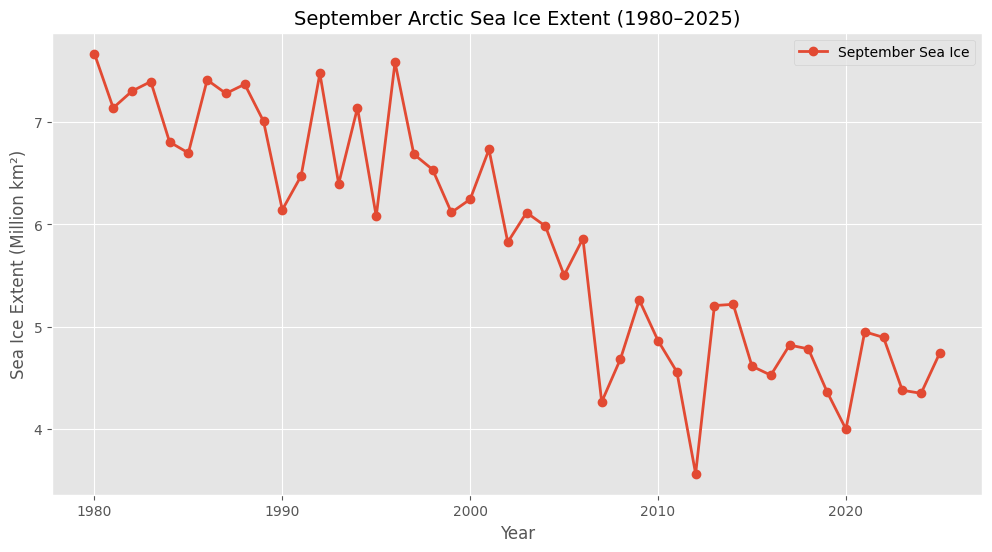

In [1113]:
plt.figure(figsize=(12,6))

plt.plot(
    final_df["winter_year"],
    final_df["september_sea_ice"],
    marker="o",
    linewidth=2,
    label="September Sea Ice"
)

plt.title("September Arctic Sea Ice Extent (1980–2025)", fontsize=14)

plt.xlabel("Year")

plt.ylabel("Sea Ice Extent (Million km²)")

plt.grid(True)

plt.legend()

plt.show()

## Long-Term Linear Trend

To summarise the overall change in September Arctic sea ice extent, a linear trend line is fitted using least-squares regression.

The trend line provides a simple representation of the long-term direction of change while smoothing over year-to-year variability.

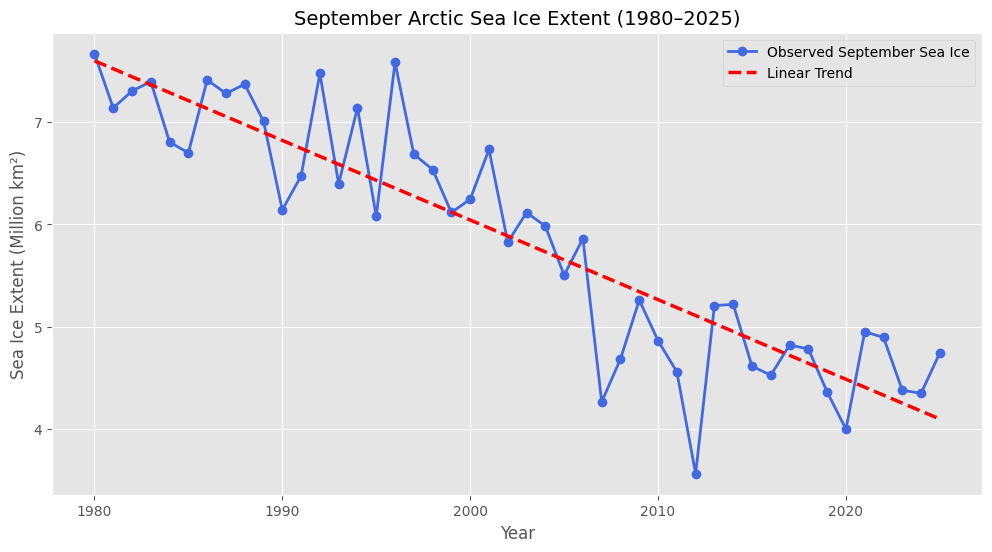

In [1114]:
# Fit a linear trend line

coefficients = np.polyfit(
    final_df["winter_year"],
    final_df["september_sea_ice"],
    deg=1
)

trend = np.poly1d(coefficients)

plt.figure(figsize=(12, 6))

# Observed sea ice
plt.plot(
    final_df["winter_year"],
    final_df["september_sea_ice"],
    marker="o",
    linewidth=2,
    color="royalblue",
    label="Observed September Sea Ice"
)

# Trend line
plt.plot(
    final_df["winter_year"],
    trend(final_df["winter_year"]),
    color="red",
    linestyle="--",
    linewidth=2.5,
    label="Linear Trend"
)

plt.title("September Arctic Sea Ice Extent (1980–2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Sea Ice Extent (Million km²)")
plt.grid(True)
plt.legend()

plt.show()

In [1115]:
print(coefficients)

[-7.77369103e-02  1.61517076e+02]


In [1116]:
trend(1979)

np.float64(7.675730434782679)

In [1117]:
trend(2025)

np.float64(4.099832562442231)

## Interpretation of the Long-Term Trend

The fitted linear trend indicates a clear long-term decline in September Arctic sea ice extent over the satellite era. The estimated slope is approximately −0.777 million km² per decade, equivalent to a loss of around 78,000 km² per year between 1980 and 2025.

A linear trend in time alone accounts for 80.3% of the variance in September sea ice extent (r = −0.896, p < 0.001). Although substantial year to year variability remains, the negative trend is highly significant and dominates the behaviour of the series.

## Relationship Between Winter Climate Variables and September Sea Ice

To investigate the second research question, scatter plots are used to visualise the relationship between each winter climate variable and September Arctic sea ice extent.

These plots help identify whether relationships appear positive, negative or non-linear before calculating correlation coefficients.

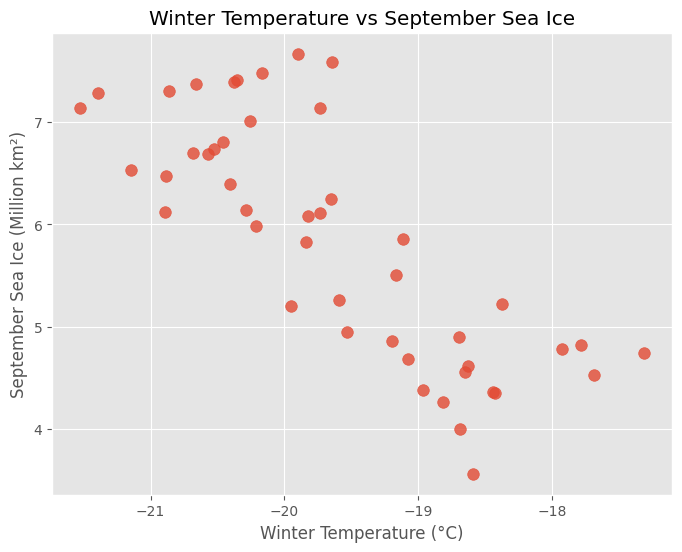

In [1118]:
plt.figure(figsize=(8,6))

plt.scatter(
    final_df["t2m"],
    final_df["september_sea_ice"],
    s=70,
    alpha=0.8
)

plt.title("Winter Temperature vs September Sea Ice")

plt.xlabel("Winter Temperature (°C)")

plt.ylabel("September Sea Ice (Million km²)")

plt.grid(True)

plt.show()

### Interpretation

The scatter plot suggests a clear negative relationship between winter Arctic temperature and September sea ice extent.

Years with warmer winter temperatures generally experience lower September sea ice extent, while colder winters are associated with higher sea ice.

Although the relationship is not perfectly linear, the overall downward trend indicates that winter temperature is likely to be an important predictor of September sea ice extent.

In [1119]:
import numpy as np
import pandas as pd
from scipy import stats

PREDICTORS = ["t2m", "msl", "u10", "v10", "wvec", "ssr"]
TARGET = "september_sea_ice"

years = final_df["winter_year"].values.astype(float)

def detrend(series, x):
    """Remove the linear trend, returning residuals about the fitted line."""
    res = stats.linregress(x, series)
    return series - (res.slope * x + res.intercept)

# Build a detrended copy of the dataset
detrended = final_df.copy()
for col in PREDICTORS + [TARGET]:
    detrended[col] = detrend(final_df[col].values, years)

# Compare raw against detrended correlations, with significance
rows = []
for v in PREDICTORS:
    raw = stats.pearsonr(final_df[v], final_df[TARGET])
    det = stats.pearsonr(detrended[v], detrended[TARGET])
    trend_r = stats.pearsonr(final_df["winter_year"], final_df[v])
    rows.append({
        "Variable": v,
        "r (raw)": round(raw.statistic, 3),
        "p (raw)": f"{raw.pvalue:.4f}",
        "r (detrended)": round(det.statistic, 3),
        "p (detrended)": f"{det.pvalue:.4f}",
        "r with year": round(trend_r.statistic, 3),
    })

comparison = pd.DataFrame(rows)

print("Correlation with September sea ice: raw vs detrended\n")
print(comparison.to_string(index=False))

# How much of the target is pure trend?
target_trend = stats.linregress(years, final_df[TARGET])
print(f"\nSeptember sea ice trend: {target_trend.slope*10:.3f} million km2 per decade")
print(f"  r = {target_trend.rvalue:.3f}, R2 = {target_trend.rvalue**2:.3f}, p = {target_trend.pvalue:.2e}")
print(f"  -> {target_trend.rvalue**2*100:.1f}% of the variance in September sea ice")
print(f"     is explained by the passage of time alone.")

Correlation with September sea ice: raw vs detrended

Variable  r (raw) p (raw)  r (detrended) p (detrended)  r with year
     t2m   -0.794  0.0000         -0.306        0.0386        0.793
     msl    0.095  0.5281          0.197        0.1904       -0.009
     u10   -0.049  0.7470         -0.217        0.1468       -0.053
     v10   -0.072  0.6329         -0.231        0.1224       -0.034
    wvec   -0.050  0.7407         -0.094        0.5354        0.010
     ssr   -0.502  0.0004         -0.057        0.7058        0.537

September sea ice trend: -0.777 million km2 per decade
  r = -0.896, R2 = 0.803, p = 3.98e-17
  -> 80.3% of the variance in September sea ice
     is explained by the passage of time alone.


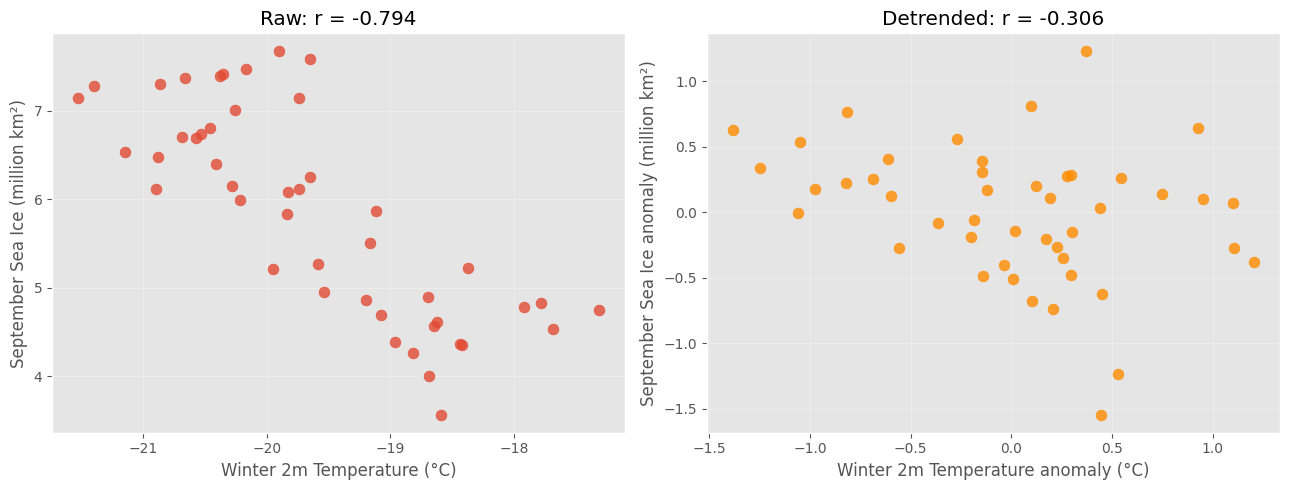

In [1120]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(final_df["t2m"], final_df["september_sea_ice"], s=60, alpha=0.8)
axes[0].set_title(f"Raw: r = {final_df['t2m'].corr(final_df['september_sea_ice']):.3f}")
axes[0].set_xlabel("Winter 2m Temperature (°C)")
axes[0].set_ylabel("September Sea Ice (million km²)")
axes[0].grid(alpha=0.3)

axes[1].scatter(detrended["t2m"], detrended["september_sea_ice"], s=60, alpha=0.8, color="darkorange")
axes[1].set_title(f"Detrended: r = {detrended['t2m'].corr(detrended['september_sea_ice']):.3f}")
axes[1].set_xlabel("Winter 2m Temperature anomaly (°C)")
axes[1].set_ylabel("September Sea Ice anomaly (million km²)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Correlation Between Winter Temperature and September Sea Ice

The Pearson correlation coefficient between winter 2 m temperature and September Arctic sea ice extent is −0.794, indicating a strong apparent negative association: warmer winters coincide with lower September extent.

This value should not be taken at face value. Both variables trend strongly over the study period, and a correlation between two trending series may reflect their common evolution in time rather than a direct physical dependence. The following section repeats the analysis on linearly detrended anomalies to separate the two.

## Correlation Analysis of Winter Climate Variables

To compare the importance of different winter climate variables, Pearson correlation coefficients are calculated between each climate variable and September Arctic sea ice extent.

Scatter plots are also produced to visualise these relationships.

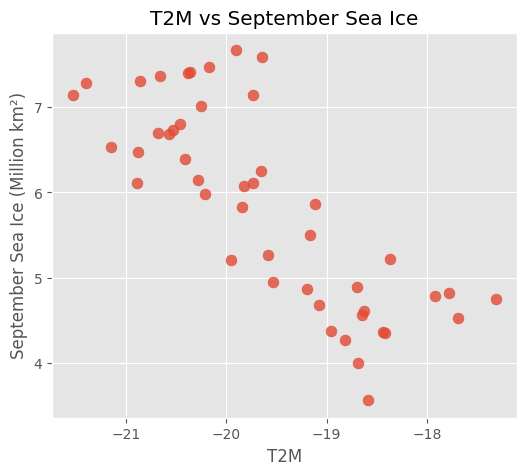

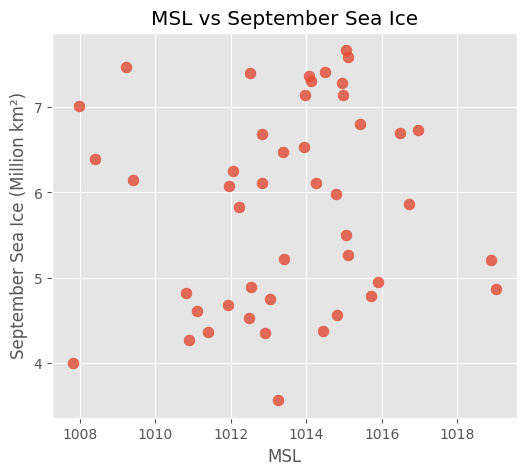

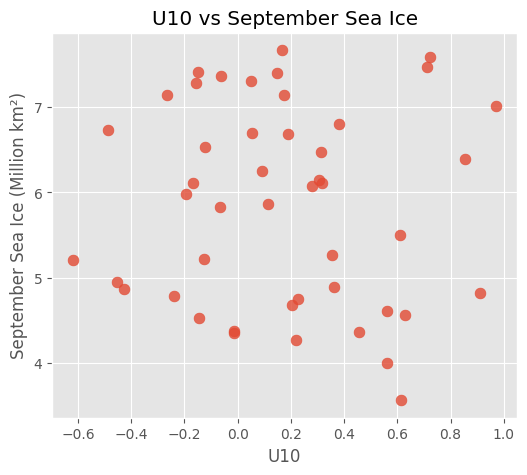

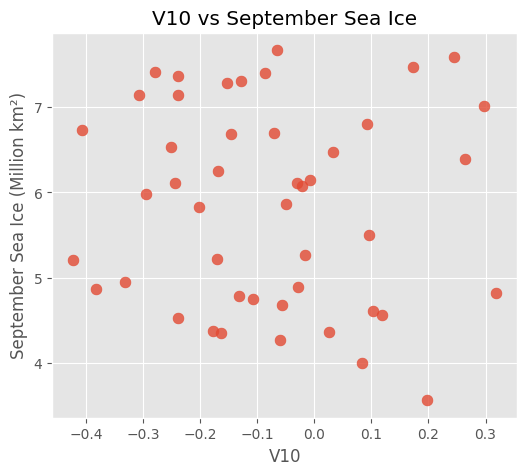

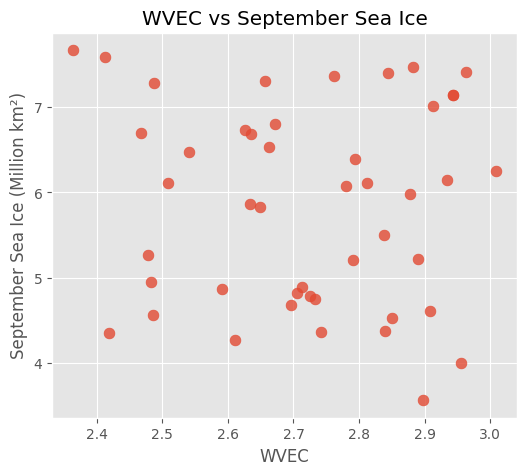

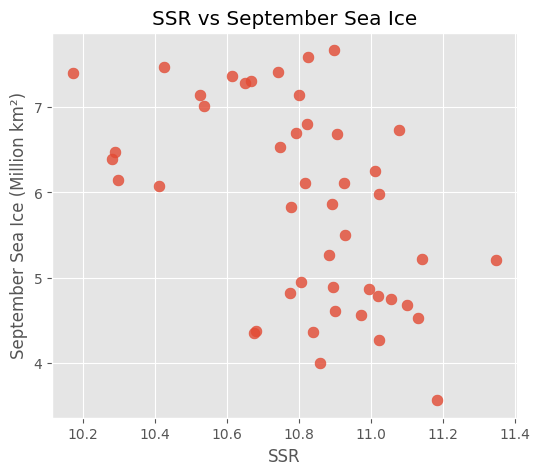

In [1121]:
climate_variables = ["t2m", "msl", "u10", "v10", "wvec", "ssr"]

for variable in climate_variables:

    plt.figure(figsize=(6,5))
    plt.scatter(final_df[variable], final_df["september_sea_ice"], s=60, alpha=0.8)
    plt.title(f"{variable.upper()} vs September Sea Ice")
    plt.xlabel(variable.upper())
    plt.ylabel("September Sea Ice (Million km²)")
    plt.grid(True)
    plt.show()

## Interpretation of Correlation Results

Two of the six winter climate variables show statistically significant raw correlations with September sea ice extent: 2 m temperature (r = −0.794, p < 0.001) and surface net solar radiation (r = −0.502, p < 0.001). The remaining variables show no significant linear association.

These raw correlations are misleading. September sea ice extent declines at −0.777 million km² per decade, and a linear trend in time alone accounts for 80.3% of its variance. Any predictor that also trends over the same period will correlate with sea ice regardless of whether a physical relationship exists.

Repeating the analysis on detrended anomalies changes the picture substantially. The correlation with 2 m temperature falls from −0.794 to −0.306 (p = 0.039), indicating that roughly three-quarters of the apparent relationship is attributable to shared trend. This residual correlation is only marginally significant and does not survive correction for multiple comparisons: with six variables tested, a Bonferroni-adjusted threshold of α = 0.0083 would be required, which p = 0.039 does not meet.

The case of surface solar radiation is more striking. Its raw correlation of −0.502 (p = 0.0004) falls to −0.057 (p = 0.71) once detrended — the apparent relationship disappears entirely. This is readily explained: winter (Dec–Mar) solar radiation over the Arctic is governed almost entirely by orbital geometry and varies by only about 2% across the record (σ = 0.26 W m⁻² on a mean of 10.8 W m⁻²). Its weak positive drift over time (r = 0.537 with year), plausibly reflecting the ice–albedo feedback as declining ice increases absorbed shortwave radiation, is sufficient to generate a spurious association with the much larger sea ice decline. This provides a clear illustration of why trend-driven correlations require careful treatment in climate time series.

No variable retains a significant correlation with September sea ice after detrending under a corrected significance threshold.

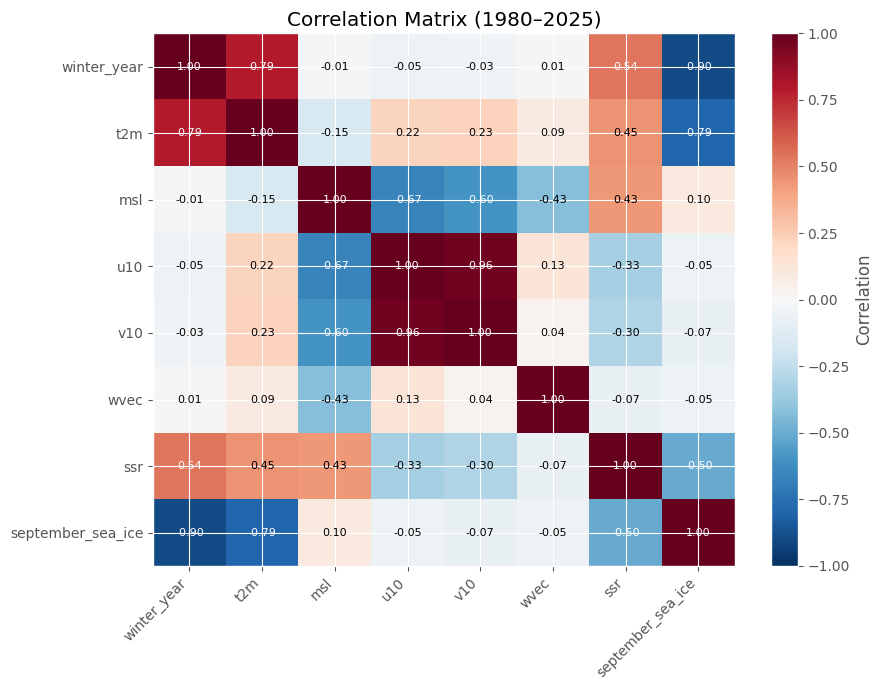

,winter_year,t2m,msl,u10,v10,wvec,ssr,september_sea_ice
winter_year,1.000,0.793,-0.009,-0.053,-0.034,0.010,0.537,-0.896
t2m,0.793,1.000,-0.150,0.219,0.227,0.092,0.446,-0.794
msl,-0.009,-0.150,1.000,-0.668,-0.600,-0.429,0.433,0.095
u10,-0.053,0.219,-0.668,1.000,0.965,0.132,-0.333,-0.049
v10,-0.034,0.227,-0.600,0.965,1.000,0.039,-0.304,-0.072
wvec,0.010,0.092,-0.429,0.132,0.039,1.000,-0.075,-0.050
ssr,0.537,0.446,0.433,-0.333,-0.304,-0.075,1.000,-0.502
september_sea_ice,-0.896,-0.794,0.095,-0.049,-0.072,-0.050,-0.502,1.000


In [1122]:
CORR_COLS = ["winter_year", "t2m", "msl", "u10", "v10", "wvec", "ssr", "september_sea_ice"]

correlation_matrix = final_df[CORR_COLS].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(CORR_COLS)), CORR_COLS, rotation=45, ha="right")
plt.yticks(range(len(CORR_COLS)), CORR_COLS)

# Annotate each cell so the figure is readable on its own
for i in range(len(CORR_COLS)):
    for j in range(len(CORR_COLS)):
        v = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{v:.2f}", ha="center", va="center",
                 color="white" if abs(v) > 0.5 else "black", fontsize=8)

plt.title("Correlation Matrix (1980–2025)")
plt.tight_layout()
plt.show()

correlation_matrix.round(3)

## Interpretation of the Correlation Matrix

The correlation matrix reveals three features relevant to the modelling that follows.

First, winter_year correlates strongly with both September sea ice (r = −0.896) and winter temperature (r = 0.793). Time is therefore the dominant organising variable in the dataset, reinforcing the need for the detrended analysis above. winter_year is not used as a physical predictor, but is retained as a trend baseline in the predictive modelling stage.

Second, the two wind components u10 and v10 are very highly correlated (r = 0.965), and both are strongly related to mean sea level pressure (r = −0.668 and −0.600 respectively). Retaining both as separate predictors would introduce severe multicollinearity, under which regression coefficients become unstable and individually uninterpretable. The modelling stage therefore uses the magnitude of the mean wind vector (wvec) in place of the individual components. This index is only moderately correlated with mean sea level pressure (r = −0.429), indicating that it contributes information not already captured by the pressure field.

Third, surface solar radiation correlates more strongly with winter_year (r = 0.537) than with any variable other than temperature, while its correlation with 2 m temperature is 0.446. This is consistent with the interpretation advanced above: in this dataset ssr behaves primarily as a slowly drifting quantity tracking the warming trend, rather than as an independent driver of interannual sea ice variability.

## Predictive Modelling

The objective of this stage is to test whether winter climate conditions carry information about the following September's sea ice extent beyond what is already available from the sea ice record itself.

Because the dataset is a chronological time series, evaluation uses an expanding-window scheme (TimeSeriesSplit, 5 folds) rather than a single train–test split or random cross-validation. In each fold the model is trained on all years up to a cut-off and evaluated on the years immediately following, so no future information ever enters the training set. With only 46 observations, averaging across five folds gives a more stable estimate of performance than any single split.

Model performance is reported as RMSE and MAE. The coefficient of determination (R²) is not used as the primary metric: September sea ice extent has been confined to a narrow range in recent years, so the variance in any short evaluation window is small and R² becomes unstable and difficult to interpret.

Three reference models are included, none of which uses climate information:

Climatology — predict the mean of the training years.
Persistence — predict the previous September's extent.
Trend only — extrapolate a linear fit in time.

These establish the standard the climate-based models must exceed. Since a linear trend alone accounts for 80.3% of the variance in the target, a model that cannot outperform the trend baseline has contributed nothing.

In [1123]:
# Merge winter climate predictors with the September sea ice target
final_df = winter_climate.merge(
    september_sea_ice,
    on="winter_year",
    how="inner"
).sort_values("winter_year").reset_index(drop=True)

# Integrity checks - fail loudly rather than silently producing nonsense
assert final_df.isnull().sum().sum() == 0, "Missing values in final dataset"
assert final_df["winter_year"].is_monotonic_increasing, "Years not in order"
assert final_df["winter_year"].is_unique, "Duplicate winter years"

print(f"Final modelling dataset: {final_df.shape[0]} winters, "
      f"{final_df['winter_year'].min()}-{final_df['winter_year'].max()}")

# Confirm the predictor-target timing is causally valid
print(f"\nEach row: winter (Dec-Mar) climate -> the FOLLOWING September sea ice")
print(final_df.head(3).round(3).to_string(index=False))

print("\nSummary:")
print(final_df.describe().round(3))

Final modelling dataset: 46 winters, 1980-2025

Each row: winter (Dec-Mar) climate -> the FOLLOWING September sea ice
 winter_year     t2m      msl   u10    v10  wvec    ssr  september_sea_ice
        1980 -19.900 1015.039 0.166 -0.065 2.364 10.898              7.667
        1981 -19.736 1013.977 0.176 -0.239 2.944 10.526              7.138
        1982 -20.862 1014.128 0.052 -0.128 2.657 10.668              7.302

Summary:
       winter_year     t2m       msl     u10     v10    wvec     ssr  \
count       46.000  46.000    46.000  46.000  46.000  46.000  46.000   
mean      2002.500 -19.622  1013.448   0.171  -0.079   2.720  10.808   
std         13.423   1.039     2.526   0.381   0.187   0.174   0.257   
min       1980.000 -21.526  1007.829  -0.617  -0.422   2.364  10.174   
25%       1991.250 -20.400  1012.099  -0.125  -0.229   2.614  10.677   
50%       2002.500 -19.736  1013.675   0.171  -0.078   2.728  10.832   
75%       2013.750 -18.723  1015.020   0.376   0.031   2.871  10.990

In [1124]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# u10/v10 excluded (r = 0.965); wvec used instead
FEATURES = ["t2m", "msl", "wvec", "ssr"]
TARGET = "september_sea_ice"

df = final_df.sort_values("winter_year").reset_index(drop=True)
df["prev_september"] = df[TARGET].shift(1)      # persistence baseline
df = df.dropna().reset_index(drop=True)         # loses 1980

y = df[TARGET].values
years = df["winter_year"].values.astype(float)

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

ALPHAS = np.logspace(-3, 3, 25)
tscv = TimeSeriesSplit(n_splits=5)
records = []

for fold, (tr, te) in enumerate(tscv.split(df), start=1):

    preds = {}

    # --- Baselines: no climate information at all ---
    preds["Climatology"] = np.full(len(te), y[tr].mean())
    preds["Persistence"] = df["prev_september"].values[te]

    trend = LinearRegression().fit(years[tr].reshape(-1, 1), y[tr])
    preds["Trend only"] = trend.predict(years[te].reshape(-1, 1))

    # --- Model A: winter climate only ---
    mA = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
    mA.fit(df.loc[tr, FEATURES], y[tr])
    preds["Climate only"] = mA.predict(df.loc[te, FEATURES])

    # --- Model B: winter climate + trend (the real test for RQ3) ---
    XB = df[FEATURES].copy()
    XB["year"] = years
    mB = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
    mB.fit(XB.iloc[tr], y[tr])
    preds["Climate + trend"] = mB.predict(XB.iloc[te])

    for name, p in preds.items():
        records.append({
            "Fold": fold,
            "Model": name,
            "RMSE": rmse(y[te], p),
            "MAE": mean_absolute_error(y[te], p),
            "n_test": len(te),
        })

results = pd.DataFrame(records)

summary = (results.groupby("Model")[["RMSE", "MAE"]]
                  .mean()
                  .round(3)
                  .sort_values("RMSE"))

# Skill score: positive = better than the trend-only baseline
ref = summary.loc["Trend only", "RMSE"]
summary["Skill vs trend"] = (1 - summary["RMSE"] / ref).round(3)

print("Expanding-window cross-validation (5 folds), mean across folds\n")
print(summary.to_string())

print("\n\nRMSE by fold:\n")
print(results.pivot(index="Fold", columns="Model", values="RMSE").round(3).to_string())

print(f"\n\nFor reference: std dev of the target = {y.std():.3f} million km²")
print("A model must beat 'Trend only' to have added anything.")

Expanding-window cross-validation (5 folds), mean across folds

                  RMSE    MAE  Skill vs trend
Model                                        
Trend only       0.663  0.564           0.000
Persistence      0.684  0.561          -0.032
Climate + trend  0.751  0.667          -0.133
Climate only     0.957  0.860          -0.443
Climatology      1.300  1.239          -0.961


RMSE by fold:

Model  Climate + trend  Climate only  Climatology  Persistence  Trend only
Fold                                                                      
1                0.573         0.575        0.576        1.000       0.601
2                0.794         0.800        0.796        0.443       0.477
3                1.312         1.814        1.823        0.723       1.078
4                0.622         0.710        1.753        0.770       0.595
5                0.455         0.887        1.551        0.484       0.564


For reference: std dev of the target = 1.132 million km²
A model must 

In [1125]:
# ============================================================
# Follow-up tests:
#   (a) Does climate predict the DETRENDED anomaly?
#   (b) Does a parsimonious t2m + year model beat 4 features?
# ============================================================

records2 = []

for fold, (tr, te) in enumerate(tscv.split(df), start=1):

    preds = {}

    # --- Reference: trend only (repeated so it appears in this table) ---
    trend = LinearRegression().fit(years[tr].reshape(-1, 1), y[tr])
    trend_te = trend.predict(years[te].reshape(-1, 1))
    preds["Trend only"] = trend_te

    # --- (a) Anomaly model -------------------------------------------
    # The trend is fitted on TRAINING years only, then used to define
    # anomalies for both train and test. Fitting it on all years would
    # leak future information into the training set.
    anom_tr = y[tr] - trend.predict(years[tr].reshape(-1, 1))

    mAnom = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
    mAnom.fit(df.loc[tr, FEATURES], anom_tr)

    # Predicted anomaly is added back onto the trend for comparability
    preds["Trend + climate anomaly"] = trend_te + mAnom.predict(df.loc[te, FEATURES])

    # --- (b) Parsimonious model: t2m + year only ----------------------
    PARSIM = ["t2m"]
    Xp = df[PARSIM].copy()
    Xp["year"] = years

    mP = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
    mP.fit(Xp.iloc[tr], y[tr])
    preds["t2m + year"] = mP.predict(Xp.iloc[te])

    # --- Full 4-feature model, for direct comparison ------------------
    XB = df[FEATURES].copy()
    XB["year"] = years
    mB = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
    mB.fit(XB.iloc[tr], y[tr])
    preds["Climate + trend (4 feat)"] = mB.predict(XB.iloc[te])

    for name, p in preds.items():
        records2.append({
            "Fold": fold,
            "Model": name,
            "RMSE": rmse(y[te], p),
            "MAE": mean_absolute_error(y[te], p),
        })

results2 = pd.DataFrame(records2)

summary2 = (results2.groupby("Model")[["RMSE", "MAE"]]
                    .mean().round(3)
                    .sort_values("RMSE"))

ref2 = summary2.loc["Trend only", "RMSE"]
summary2["Skill vs trend"] = (1 - summary2["RMSE"] / ref2).round(3)

print("Follow-up comparison (5-fold expanding window)\n")
print(summary2.to_string())

print("\n\nRMSE by fold:\n")
print(results2.pivot(index="Fold", columns="Model", values="RMSE").round(3).to_string())

# Excluding fold 3, which spans the 2007 regime shift
print("\n\nExcluding fold 3 (regime shift):\n")
print(results2[results2["Fold"] != 3]
      .groupby("Model")["RMSE"].mean().round(3)
      .sort_values().to_string())

Follow-up comparison (5-fold expanding window)

                           RMSE    MAE  Skill vs trend
Model                                                 
Trend only                0.663  0.564           0.000
Trend + climate anomaly   0.664  0.565          -0.002
t2m + year                0.713  0.619          -0.075
Climate + trend (4 feat)  0.751  0.667          -0.133


RMSE by fold:

Model  Climate + trend (4 feat)  Trend + climate anomaly  Trend only  t2m + year
Fold                                                                            
1                         0.573                    0.601       0.601       0.574
2                         0.794                    0.480       0.477       0.790
3                         1.312                    1.078       1.078       1.059
4                         0.622                    0.594       0.595       0.638
5                         0.455                    0.566       0.564       0.503


Excluding fold 3 (regime shift):

Mo

 Year  Actual  Trend only  Trend + climate  Error (trend)
 2017   4.822       4.491            4.475          0.331
 2018   4.785       4.403            4.396          0.382
 2019   4.364       4.315            4.304          0.049
 2020   4.001       4.227            4.212         -0.226
 2021   4.952       4.140            4.141          0.812
 2022   4.897       4.052            4.044          0.845
 2023   4.381       3.964            3.960          0.417
 2024   4.351       3.877            3.867          0.474
 2025   4.747       3.789            3.775          0.958

Hold-out RMSE  | Trend only: 0.577  | Trend + climate: 0.583
Mean absolute adjustment from climate variables: 0.0096 million km²

Standardised coefficients (anomaly model):
  t2m    -0.0049
  msl    +0.0036
  wvec   -0.0003
  ssr    +0.0010


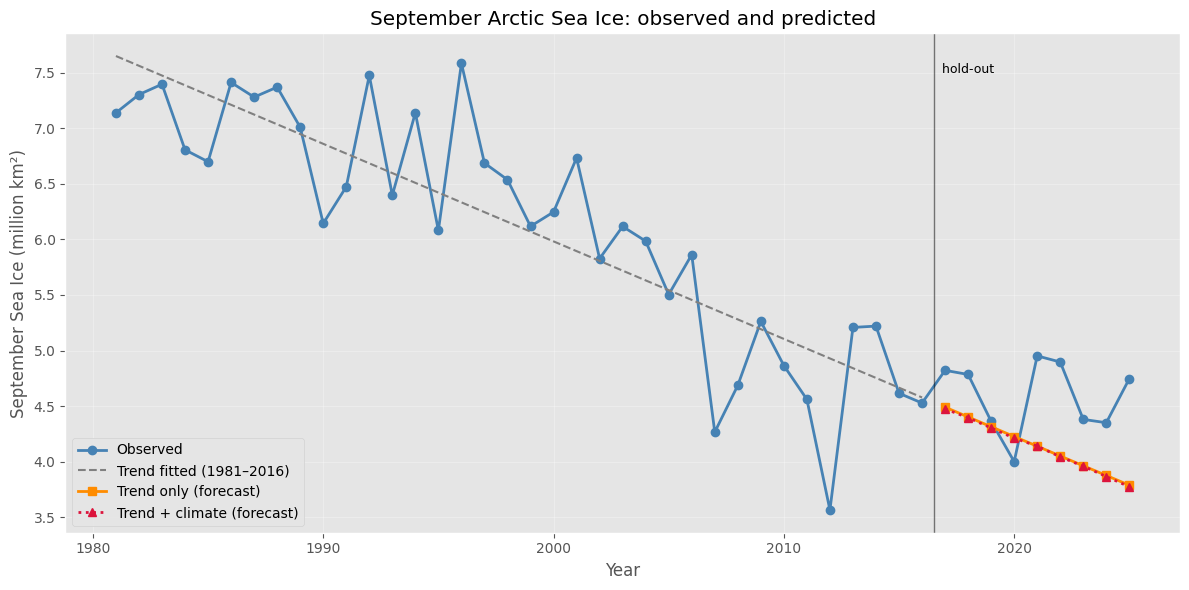

In [1126]:
# ============================================================
# Diagnostics for the best-performing configuration
# Fitted on 1981-2016, evaluated on 2017-2025
# ============================================================

hold = df["winter_year"] >= 2017
tr_idx = np.where(~hold)[0]
te_idx = np.where(hold)[0]

# Trend only
trend_f = LinearRegression().fit(years[tr_idx].reshape(-1, 1), y[tr_idx])
pred_trend = trend_f.predict(years[te_idx].reshape(-1, 1))

# Trend + climate anomaly
anom_tr = y[tr_idx] - trend_f.predict(years[tr_idx].reshape(-1, 1))
m_anom = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
m_anom.fit(df.loc[tr_idx, FEATURES], anom_tr)
pred_anom = pred_trend + m_anom.predict(df.loc[te_idx, FEATURES])

diagnostics = pd.DataFrame({
    "Year": df.loc[te_idx, "winter_year"].values,
    "Actual": y[te_idx],
    "Trend only": pred_trend.round(3),
    "Trend + climate": pred_anom.round(3),
    "Error (trend)": (y[te_idx] - pred_trend).round(3),
})

print(diagnostics.to_string(index=False))
print(f"\nHold-out RMSE  | Trend only: {rmse(y[te_idx], pred_trend):.3f}"
      f"  | Trend + climate: {rmse(y[te_idx], pred_anom):.3f}")

# How much did the climate variables shift the prediction?
shift = np.abs(pred_anom - pred_trend)
print(f"Mean absolute adjustment from climate variables: {shift.mean():.4f} million km²")

# Ridge coefficients on the anomaly model
print("\nStandardised coefficients (anomaly model):")
for f, c in zip(FEATURES, m_anom[-1].coef_):
    print(f"  {f:6s} {c:+.4f}")

# ---- Figure: full record, fit and forecast ----
plt.figure(figsize=(12, 6))
plt.plot(df["winter_year"], y, marker="o", lw=2, color="steelblue", label="Observed")
plt.plot(df.loc[tr_idx, "winter_year"], trend_f.predict(years[tr_idx].reshape(-1, 1)),
         ls="--", color="grey", label="Trend fitted (1981–2016)")
plt.plot(diagnostics["Year"], diagnostics["Trend only"],
         marker="s", lw=2, color="darkorange", label="Trend only (forecast)")
plt.plot(diagnostics["Year"], diagnostics["Trend + climate"],
         marker="^", lw=2, ls=":", color="crimson", label="Trend + climate (forecast)")
plt.axvline(2016.5, color="black", lw=1, alpha=0.5)
plt.text(2016.7, y.max(), " hold-out", va="top", fontsize=9)
plt.xlabel("Year")
plt.ylabel("September Sea Ice (million km²)")
plt.title("September Arctic Sea Ice: observed and predicted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model Explainability

Research Question 4 asks which variables contribute most to model predictions, and whether those contributions are scientifically interpretable. Two complementary methods are used: standardised regression coefficients, which show the direction and magnitude of each variable's linear contribution, and permutation importance, which measures how much predictive performance degrades when a variable's values are randomly shuffled.

Permutation importance is included because coefficients alone can be misleading on small, correlated datasets. Because all predictors are standardised before fitting, coefficient magnitudes are directly comparable across variables despite their differing physical units.

Standardised coefficients (climate + trend model)

Feature  Std. coefficient
   year           -0.6381
    t2m           -0.2968
    ssr           -0.1442
    msl            0.1240
   wvec            0.0450

Selected Ridge alpha: 3.162


Permutation importance (RMSE increase when shuffled)

Feature  Increase in RMSE    Std
   year            0.5846 0.0756
    t2m            0.1698 0.0406
    ssr            0.0477 0.0210
    msl            0.0330 0.0162
   wvec            0.0043 0.0064

A value near zero means the variable contributes nothing:
shuffling it does not make predictions worse.


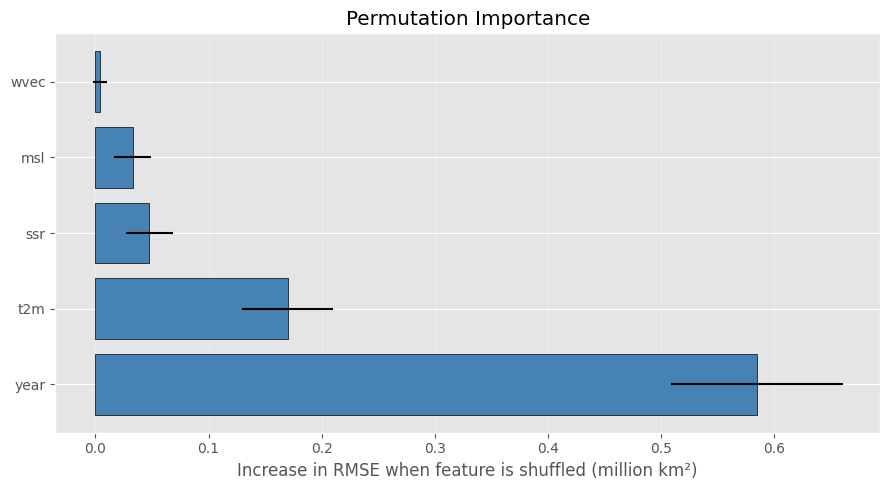

In [1127]:
from sklearn.inspection import permutation_importance

# Fit the climate + trend model on the full record for interpretation
X_full = df[FEATURES].copy()
X_full["year"] = years

model_full = make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS))
model_full.fit(X_full, y)

# --- Standardised coefficients ---
coefs = pd.DataFrame({
    "Feature": list(X_full.columns),
    "Std. coefficient": model_full[-1].coef_.round(4)
}).sort_values("Std. coefficient", key=abs, ascending=False)

print("Standardised coefficients (climate + trend model)\n")
print(coefs.to_string(index=False))
print(f"\nSelected Ridge alpha: {model_full[-1].alpha_:.3f}")

# --- Permutation importance ---
perm = permutation_importance(
    model_full, X_full, y,
    n_repeats=100, random_state=42,
    scoring="neg_root_mean_squared_error"
)

importance = pd.DataFrame({
    "Feature": list(X_full.columns),
    "Increase in RMSE": perm.importances_mean.round(4),
    "Std": perm.importances_std.round(4)
}).sort_values("Increase in RMSE", ascending=False)

print("\n\nPermutation importance (RMSE increase when shuffled)\n")
print(importance.to_string(index=False))
print("\nA value near zero means the variable contributes nothing:")
print("shuffling it does not make predictions worse.")

# --- Figure ---
plt.figure(figsize=(9, 5))
plt.barh(importance["Feature"], importance["Increase in RMSE"],
         xerr=importance["Std"], color="steelblue", edgecolor="black")
plt.xlabel("Increase in RMSE when feature is shuffled (million km²)")
plt.title("Permutation Importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation

Both methods identify year as by far the dominant predictor. Its standardised coefficient (−0.638) is more than twice that of any climate variable, and shuffling it increases RMSE by 0.585 million km², over three times the effect of the next most important feature. This is consistent with the finding that a linear trend in time alone explains 80.3% of the variance in September sea ice extent.

Among the climate variables, 2 m temperature is the most influential (coefficient −0.297; permutation importance 0.170 ± 0.041). Its negative sign is physically plausible: warmer winters are associated with lower subsequent September extent. Surface solar radiation and mean sea level pressure show small contributions (0.048 and 0.033 respectively), and the wind vector index is negligible (0.004 ± 0.006, an interval spanning zero).

An apparent tension arises between these results and the cross-validation in the previous section, where adding climate variables did not improve predictive performance. The two analyses measure different things. Permutation importance quantifies how much a model fitted to the full record relies on each variable; cross-validation quantifies whether that reliance improves forecasts of unseen years. Because winter temperature is itself strongly correlated with time (r = 0.793), the fitted model uses it as a partial proxy for the trend. Removing it forces greater reliance on year alone and degrades the in-sample fit, but the information it supplies is largely redundant with the trend and therefore confers no out-of-sample advantage. The Ridge penalty selected (α = 3.162) reflects substantial shrinkage, consistent with predictors that carry limited independent signal.

In answer to Research Question 4: winter 2 m temperature is the most influential climate variable and its effect is directionally interpretable, but its contribution is largely redundant with the long-term trend rather than independent of it. No climate variable demonstrates predictive value beyond what time alone provides.

## Change Point Analysis of the September Trend

The evaluation above revealed that the linear trend baseline, though the best available predictor, systematically over predicts decline in recent years. Errors on the 2017 to 2025 hold out are almost uniformly positive and grow from 0.33 to 0.96 million km². This section tests directly whether a single linear trend adequately describes the full record, or whether the rate of decline has changed.

The approach fits a piecewise linear model with one break point, searching over all candidate years and selecting the break that minimises residual sum of squares. Because a two segment model has more parameters than a single line and will always fit at least as well, model selection uses the Bayesian Information Criterion, which penalises additional parameters. A formal Chow test then assesses whether the improvement is statistically significant.

The minimum segment length was set to 8 years to ensure stable fits at both ends of the record. The identified break point is insensitive to this choice: repeating the search with minimum segment lengths of 5 and 10 years returns 2007 in both cases, with identical test statistics (RSS = 7.688, F = 11.825, p = 0.0001).

Best five candidate break points

 Break year   RSS  Slope before  Slope after
       2007 7.688        -0.588       -0.067
       2005 8.736        -0.530       -0.306
       2006 8.774        -0.581       -0.233
       2004 9.394        -0.512       -0.414
       2008 9.707        -0.707       -0.152


Single linear trend : RSS = 12.017, BIC = -50.26
Two segment model   : RSS = 7.688, BIC = -59.32
BIC difference      : +9.06  (positive favours the break)

Chow test: F = 11.825, p = 0.0001
Best break year: 2007
  Trend before: -0.588 million km2 per decade
  Trend after : -0.067 million km2 per decade


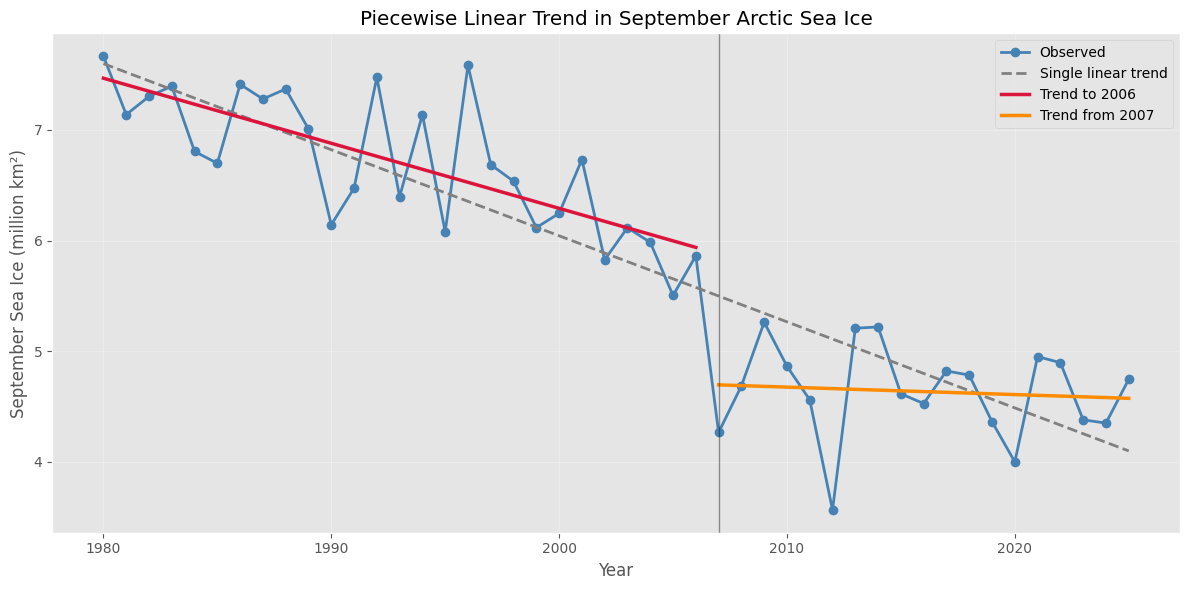

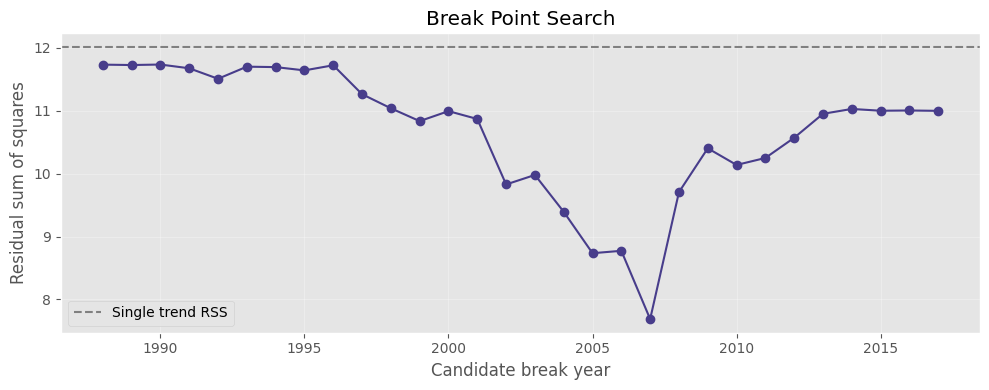

In [1128]:
from scipy import stats as sps

yr = final_df["winter_year"].values.astype(float)
ice = final_df["september_sea_ice"].values
n = len(yr)

def fit_rss(x, z):
    """Fit a straight line, return residual sum of squares."""
    r = sps.linregress(x, z)
    return float(np.sum((z - (r.slope * x + r.intercept)) ** 2)), r

# --- Single linear trend (null model) ---
rss1, fit1 = fit_rss(yr, ice)

# --- Search for the best single break point ---
MIN_SEG = 8   # require at least 8 years either side for a stable fit
rows = []

for i in range(MIN_SEG, n - MIN_SEG):
    cut = yr[i]
    left, right = yr < cut, yr >= cut
    rss_l, fl = fit_rss(yr[left], ice[left])
    rss_r, fr = fit_rss(yr[right], ice[right])
    rows.append({
        "Break year": int(cut),
        "RSS": rss_l + rss_r,
        "Slope before": fl.slope * 10,
        "Slope after": fr.slope * 10,
    })

search = pd.DataFrame(rows).sort_values("RSS")
best = search.iloc[0]
rss2 = best["RSS"]

# --- Model selection: BIC (lower is better) ---
def bic(rss, n, k):
    return n * np.log(rss / n) + k * np.log(n)

bic1 = bic(rss1, n, 3)   # slope, intercept, sigma
bic2 = bic(rss2, n, 6)   # two slopes, two intercepts, break, sigma

# --- Chow test for a structural break ---
k = 4                                    # params in the two segment model
F = ((rss1 - rss2) / (k - 2)) / (rss2 / (n - k))
p_chow = 1 - sps.f.cdf(F, k - 2, n - k)

print("Best five candidate break points\n")
print(search.head(5).round(3).to_string(index=False))

print(f"\n\nSingle linear trend : RSS = {rss1:.3f}, BIC = {bic1:.2f}")
print(f"Two segment model   : RSS = {rss2:.3f}, BIC = {bic2:.2f}")
print(f"BIC difference      : {bic1 - bic2:+.2f}  (positive favours the break)")
print(f"\nChow test: F = {F:.3f}, p = {p_chow:.4f}")
print(f"Best break year: {int(best['Break year'])}")
print(f"  Trend before: {best['Slope before']:.3f} million km2 per decade")
print(f"  Trend after : {best['Slope after']:.3f} million km2 per decade")

# --- Figure ---
cut = best["Break year"]
left, right = yr < cut, yr >= cut
_, fl = fit_rss(yr[left], ice[left])
_, fr = fit_rss(yr[right], ice[right])

plt.figure(figsize=(12, 6))
plt.plot(yr, ice, marker="o", lw=2, color="steelblue", label="Observed")
plt.plot(yr, fit1.slope * yr + fit1.intercept, ls="--", color="grey",
         lw=2, label="Single linear trend")
plt.plot(yr[left], fl.slope * yr[left] + fl.intercept, color="crimson",
         lw=2.5, label=f"Trend to {int(cut)-1}")
plt.plot(yr[right], fr.slope * yr[right] + fr.intercept, color="darkorange",
         lw=2.5, label=f"Trend from {int(cut)}")
plt.axvline(cut, color="black", lw=1, alpha=0.4)
plt.xlabel("Year")
plt.ylabel("September Sea Ice (million km²)")
plt.title("Piecewise Linear Trend in September Arctic Sea Ice")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Sensitivity: how sharply defined is the break? ---
plt.figure(figsize=(10, 4))
plt.plot(search.sort_values("Break year")["Break year"],
         search.sort_values("Break year")["RSS"], marker="o", color="darkslateblue")
plt.axhline(rss1, ls="--", color="grey", label="Single trend RSS")
plt.xlabel("Candidate break year")
plt.ylabel("Residual sum of squares")
plt.title("Break Point Search")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [1129]:
# Is the post-2007 trend distinguishable from zero?
post = yr >= 2007
r_post = sps.linregress(yr[post], ice[post])
print(f"Post-2007 trend: {r_post.slope*10:.3f} million km2/decade")
print(f"  std err {r_post.stderr*10:.3f}, p = {r_post.pvalue:.3f}, n = {post.sum()}")

# Does the piecewise model forecast the hold-out better than a single line?
tr = yr < 2017
post07 = tr & (yr >= 2007)
f_single = sps.linregress(yr[tr], ice[tr])
f_piece  = sps.linregress(yr[post07], ice[post07])

te = yr >= 2017
p_single = f_single.slope*yr[te] + f_single.intercept
p_piece  = f_piece.slope*yr[te] + f_piece.intercept
print(f"\nHold-out RMSE | single trend: {np.sqrt(np.mean((ice[te]-p_single)**2)):.3f}"
      f" | piecewise: {np.sqrt(np.mean((ice[te]-p_piece)**2)):.3f}")

Post-2007 trend: -0.067 million km2/decade
  std err 0.183, p = 0.717, n = 19

Hold-out RMSE | single trend: 0.573 | piecewise: 0.361


## Discussion

## Summary of Findings

This project investigated whether winter climate conditions over the Arctic (December to March, 60°N to 90°N) carry information about the following September's sea ice extent, using ERA5 reanalysis variables and NSIDC Sea Ice Index observations for 46 winters spanning 1980 to 2025.

## Research Question 1: How has Arctic sea ice extent changed over the satellite period?

September Arctic sea ice extent declined at 0.777 million km² per decade between 1980 and 2025 (r = 0.896 negative, p < 10⁻¹⁶). A linear trend in time alone accounts for 80.3% of the variance in the series. Decline is evident in every month of the year, with the largest absolute losses in late summer.

## Research Question 2: Which climate variables show the strongest relationship with sea ice extent?

In raw form, two variables correlate significantly with September extent: 2 m temperature (r = 0.794 negative) and surface net solar radiation (r = 0.502 negative). Both relationships weaken substantially once the linear trend is removed from each series. The correlation with temperature falls to 0.306 negative (p = 0.039), and that with solar radiation to 0.057 negative (p = 0.71). Neither survives a Bonferroni corrected threshold of α = 0.0083 for six simultaneous tests.

The solar radiation result illustrates the hazard of trend driven correlation particularly clearly. Winter solar radiation over the Arctic is governed almost entirely by orbital geometry and varies by only about 2% across the record (σ = 0.26 W m⁻² on a mean of 10.8 W m⁻²). Its slight upward drift over time, plausibly reflecting the ice albedo feedback whereby reduced ice cover increases absorbed shortwave radiation, is sufficient to generate an apparently significant association with a target that has halved over the same period. The relationship is a statistical artefact of two series sharing a trend, not evidence of a physical driver.

## Research Question 3: Can climate variables improve prediction over sea ice observations alone?

No. Under expanding window cross validation, no configuration using winter climate variables outperformed a linear trend baseline (RMSE 0.663 million km²). A model using climate variables alone scored 0.957, and combining them with a trend term scored 0.751, worse than the trend by itself, indicating that the additional parameters cost more in variance than they returned in signal on a 46 observation dataset.

The most direct test was to supply the trend to the model and ask the climate variables to explain only the departures from it. That configuration scored 0.664 against the trend baseline's 0.663, a skill score of 0.002 negative. On the 2017 to 2025 hold out, the climate variables adjusted predictions by a mean of 0.0096 million km², against a target standard deviation of 1.13. The regularised model, given four winter climate variables, effectively declined to use them.

## Research Question 4: Which variables contribute most, and are the contributions interpretable?

Time dominates both standardised coefficients and permutation importance. Among climate variables, 2 m temperature is the most influential and its negative sign is physically plausible, but its contribution is largely redundant with the trend rather than independent of it. This is discussed in the explainability section above.

## Limitations

## Several constraints bound the interpretation of these results.

**Spatial aggregation** Each climate variable is reduced to a single area weighted mean over 60°N to 90°N. This discards all spatial structure. Regional anomalies known to influence sea ice, such as Atlantic inflow through the Barents Sea, the Beaufort Gyre circulation, and the position of the Arctic front, average out entirely. A domain wide mean may simply be too coarse a summary to retain a predictive signal.

**Temporal aggregation** Averaging December through March into one value removes sub seasonal information. Physically, the timing of a warm anomaly may matter more than its seasonal mean: a warm March affects the onset of melt very differently from a warm December.

**Sample size** With 46 annual observations and up to five predictors, statistical power is limited and models are prone to overfitting. This is an inherent constraint of the satellite record, not a design choice.

**Variable coverage** Sea surface temperature, ocean heat content, sea ice thickness and precipitation are all physically relevant and were not included. Ice thickness in particular is a recognised source of predictive skill for September extent and its absence is a substantive gap.

Linearity. All models tested here are linear. Non linear methods were not explored in depth; given the sample size, they would require careful regularisation and validation to avoid overfitting.

## A Structural Break in 2007

The evaluation in Section 8 revealed that the linear trend baseline, though the strongest available predictor, systematically over predicts decline in recent years, with hold out errors growing from 0.33 to 0.96 million km² between 2017 and 2025. Section 9.5 tested whether this reflects a change in the rate of decline rather than random variation.

A piecewise linear model with a single break point substantially outperforms a single linear trend. The break is located at 2007 and is both statistically significant and well identified. The Chow test gives F = 11.825 with p = 0.0001, and the Bayesian Information Criterion favours the two segment model by 9.06 despite its three additional parameters. The break point is robust to the minimum segment length imposed on the search, returning 2007 for values of 5, 8 and 10 years.

The two regimes are qualitatively different. Between 1980 and 2006, September extent declined at 0.588 million km² per decade. From 2007 onward the estimated trend is 0.067 million km² per decade with a standard error of 0.183 and p = 0.717, statistically indistinguishable from zero. Over the last nineteen years of the record, September Arctic sea ice extent shows no detectable linear trend, fluctuating around a mean of approximately 4.6 million km².

That 2007 emerges from an unguided search over all candidate years is notable. It corresponds to the first major Arctic sea ice collapse, when September extent fell to 4.27 million km² and greatly exceeded the previous record minimum. The break point was identified from the data alone, without reference to this event.

The practical consequence is direct. Fitting the trend only to the post 2007 regime reduces hold out RMSE on 2017 to 2025 from 0.573 to 0.361 million km², an improvement of 37%. For context, the standard deviation of observed extent across those nine years is 0.31 million km², so the piecewise forecast approaches the limit set by interannual variability. The failure of the linear baseline documented earlier is therefore not an inherent limit on predictability but a consequence of model misspecification: a single line fitted across two regimes inherits a decline rate that ceased to apply in 2007 and projects it forward.

One caveat should be stated. The break point was identified using the full record and subsequently evaluated on a subset of it, which introduces a degree of optimism into the hold out comparison. The break year and the evaluation period are disjoint, and the 2007 event is independently documented in the literature, but the improvement figure should be understood as an in sample estimate rather than a fully independent validation.

## Conclusions

This project set out to test whether winter climate conditions over the Arctic carry predictive information about the following September's sea ice extent. It reaches two conclusions, one negative and one positive.

The negative conclusion concerns the climate variables themselves. Winter 2 m temperature, mean sea level pressure, wind and surface solar radiation, aggregated over the Arctic basin, provide no predictive information about September sea ice extent beyond what the sea ice record already supplies. Apparent correlations between these variables and September extent are substantially artefacts of shared trends: the raw correlation with winter temperature of 0.794 negative falls to 0.306 negative once both series are detrended, and does not survive correction for multiple comparisons. Under chronological cross validation, no configuration using climate variables outperformed a trend baseline, and a regularised model given the trend and asked to explain only departures from it adjusted its predictions by a mean of 0.0096 million km², effectively declining to use the climate information at all.

The positive conclusion concerns the baseline. September Arctic sea ice extent does not follow a single linear trend over the satellite era. A structural break in 2007 separates a regime of significant decline at 0.588 million km² per decade from a subsequent regime showing no detectable trend at all. Correcting for this misspecification reduces hold out forecast error by 37%. The linear trend model in common use is therefore not merely a weak baseline but an actively biased one in the current period, and it progressively over predicts decline as the extrapolation extends further from the pre 2007 data that determine its slope.

These conclusions are connected. The failure of the climate variables was initially interpretable as a limit on seasonal predictability. The change point analysis shows that a substantial part of the apparent forecast error was attributable to the reference model rather than to the difficulty of the problem. This illustrates a general point about model evaluation: a poorly specified baseline both understates achievable skill and obscures the source of error.

The methodological practices adopted here were each necessary to reach these conclusions. Area weighted spatial averaging, strict seasonal completeness criteria, detrended correlation analysis with correction for multiple comparisons, chronological rather than random cross validation, and explicit comparison against climatology, persistence and trend baselines. Without detrending, winter temperature would have appeared a strong predictor. Without baselines, the models would have had no reference point. Without the change point analysis, the trend baseline's failure would have been mistaken for an intrinsic property of the system.

## Suggested Further Work

**Four directions follow from these results.**

**Independent validation of the piecewise model** The break point here was identified using the full record. A properly independent test would identify the break using data to a fixed cut off and evaluate forecasts on subsequent years never used in the search.

**Characterising the post 2007 regime** If September extent has no linear trend since 2007, the appropriate model for that period is not a trend at all but a description of variability about a mean level. Whether that level is stable, and what governs departures from it, is an open question that this dataset alone cannot resolve.

**Regional and sub seasonal disaggregation** The null result for climate variables was obtained at the coarsest possible aggregation, a single basin wide winter mean per variable. Regional indices targeting the Barents and Beaufort sectors, or monthly rather than seasonal predictors, would test whether the signal is present but destroyed by averaging.

**Sea ice thickness** Thickness and volume carry information about the ice's capacity to survive the melt season that extent does not. Their absence is the most substantial gap in the predictor set, and their inclusion is the change most likely to alter the negative conclusion above.